# 02 — Stochastic Debt Sustainability Analysis

This notebook builds a stochastic debt sustainability analysis (DSA) for France.

It separates two accounting layers:

1. **AFT negotiable French State debt** — detailed refinancing and interest-cost transmission.
2. **French general-government debt** — broader debt/GDP sustainability.

The AFT portfolio is not treated as the whole French public-debt stock. Instead, the AFT engine estimates the **incremental financing-cost effect of market deviations** relative to a central AFT path.

The key bridge is:

\[
\Delta IC_t^{AFT}
=
IC_t^{AFT,stochastic}
-
IC_t^{AFT,central}
\]

The general-government central path is calibrated to the IMF 2026 Article IV baseline through 2031. The stochastic general-government path then applies the central GG effective rate to the stochastic debt stock and adds only the incremental AFT financing-cost shock.

Stages:

1. Load and validate the AFT portfolio.
2. Run standalone deterministic AFT yield sensitivities.
3. Calibrate stochastic processes from historical data.
4. Build an IMF-consistent 2026–2041 central scenario.
5. Generate a robust stochastic macro/market path.
6. Run both central and stochastic AFT portfolios.
7. Build and validate the central general-government path.
8. Transfer only the AFT cost deviation from central into the stochastic GG DSA.

In [241]:
from pathlib import Path
from io import StringIO, BytesIO
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from sklearn.covariance import LedoitWolf, MinCovDet
from scipy.stats import chi2

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

from src.models.debt_portfolio import (
    load_portfolio,
    portfolio_summary,
    maturity_schedule,
    total_debt,
    annual_coupon_expense,
    portfolio_coupon_rate,
    simulate_portfolio_path,
    curve_from_30y_anchor,
)

RANDOM_SEED = 42
print("Project root:", PROJECT_ROOT)

Project root: c:\Users\mikel\Desktop\french_oat_model


## 1. Load the validated AFT portfolio

In [242]:
SNAPSHOT_DATE = pd.Timestamp("2026-10-03")

PORTFOLIO_PATH = (
    PROCESSED_DIR
    / f"aft_portfolio_{SNAPSHOT_DATE.date()}.csv"
)

portfolio = load_portfolio(
    PORTFOLIO_PATH,
    snapshot_date=SNAPSHOT_DATE,
)

print(f"Securities loaded: {len(portfolio):,}")
print(f"AFT indexed liability: €{total_debt(portfolio) / 1e12:.3f}tn")
print(f"Annual coupon cash: €{annual_coupon_expense(portfolio) / 1e9:.1f}bn")
print(f"Portfolio coupon rate: {portfolio_coupon_rate(portfolio):.2%}")

Securities loaded: 103
AFT indexed liability: €2.928tn
Annual coupon cash: €54.3bn
Portfolio coupon rate: 1.85%


In [243]:
portfolio_summary(portfolio)

,security_type,securities,face_value_eur,liability_principal_eur,annual_coupon_eur
0,BTF,27,2.176580e+11,2.176580e+11,0.000000e+00
1,OAT,58,2.393007e+12,2.393007e+12,5.129826e+10
2,OATEI,13,1.860690e+11,2.467825e+11,2.372800e+09
3,OATI,5,5.659614e+10,7.075309e+10,6.187138e+08


In [244]:
maturity_schedule(portfolio).head(15)

,maturity_year,face_value_eur,liability_principal_eur,redemption_value_eur,coupon_eur,securities
0,2026,1.401160e+11,1.401160e+11,1.401160e+11,9.112000e+07,14
1,2027,3.013690e+11,3.103053e+11,3.103053e+11,3.379104e+09,19
2,2028,2.458292e+11,2.498378e+11,2.498378e+11,2.527787e+09,6
3,2029,2.837430e+11,2.957532e+11,2.957532e+11,5.839108e+09,7
4,2030,2.102590e+11,2.158372e+11,2.158372e+11,3.665894e+09,4
5,2031,2.079180e+11,2.115155e+11,2.115155e+11,2.785882e+09,4
6,2032,2.050923e+11,2.170086e+11,2.170086e+11,5.097588e+09,6
7,2033,1.138450e+11,1.138450e+11,1.138450e+11,3.731595e+09,2
8,2034,1.302310e+11,1.320922e+11,1.320922e+11,2.471632e+09,3
9,2035,1.514990e+11,1.514990e+11,1.514990e+11,5.609866e+09,3


## 2. General-government starting calibration

In [245]:
# ============================================================
# IMF-consistent starting point: end-2026
# ============================================================

BASELINE = {
    "initial_gdp_eur": 3_056e9,
    "initial_debt_gdp": 1.185,
    "initial_primary_balance_gdp": -0.027,
    "initial_interest_gdp": 0.025,

    # Used only by the standalone deterministic AFT section
    "real_growth": 0.009,
    "inflation": 0.017,

    "start_year": 2027,
    "horizon_years": 15,
}

BASELINE["nominal_growth"] = (
    (1 + BASELINE["real_growth"])
    * (1 + BASELINE["inflation"])
    - 1
)

INITIAL_GG_DEBT_EUR = (
    BASELINE["initial_gdp_eur"]
    * BASELINE["initial_debt_gdp"]
)

print(f"Initial general-government GDP: €{BASELINE['initial_gdp_eur'] / 1e12:.3f}tn")
print(f"Initial general-government debt: €{INITIAL_GG_DEBT_EUR / 1e12:.3f}tn")
print(f"Initial debt/GDP: {BASELINE['initial_debt_gdp']:.1%}")
print(f"Initial primary balance/GDP: {BASELINE['initial_primary_balance_gdp']:.1%}")
print(f"2026 interest/GDP: {BASELINE['initial_interest_gdp']:.1%}")

Initial general-government GDP: €3.056tn
Initial general-government debt: €3.621tn
Initial debt/GDP: 118.5%
Initial primary balance/GDP: -2.7%
2026 interest/GDP: 2.5%


## 3. Deterministic AFT baseline and 7% stress

In [246]:
CURRENT_YEAR = 2026
CURRENT_OAT_30Y = 0.0517

# Observed October-2026 nominal 30Y OAT anchor.
BASELINE_OAT_30Y = CURRENT_OAT_30Y

NOMINAL_CURVE_OFFSETS_TO_30Y = {
    1.0:  -0.0150,
    2.0:  -0.0125,
    5.0:  -0.0100,
    10.0: -0.0060,
    15.0: -0.0035,
    30.0:  0.0000,
    50.0:  0.0015,
}

baseline_nominal_curve = curve_from_30y_anchor(
    oat_30y_yield=BASELINE_OAT_30Y,
    offsets_to_30y=NOMINAL_CURVE_OFFSETS_TO_30Y,
)

baseline_real_euro_curve = {
    5.0: 0.020,
    10.0: 0.025,
    20.0: 0.028,
    30.0: 0.030,
}

baseline_real_fr_curve = {
    5.0: 0.021,
    10.0: 0.026,
    20.0: 0.029,
    30.0: 0.031,
}

baseline_market_curves = {
    "nominal": baseline_nominal_curve,
    "real_euro": baseline_real_euro_curve,
    "real_fr": baseline_real_fr_curve,
}

ISSUANCE_PLAN = [
    {"security_type": "BTF",   "maturity_years": 1.0,  "weight": 0.10},
    {"security_type": "OAT",   "maturity_years": 2.0,  "weight": 0.10},
    {"security_type": "OAT",   "maturity_years": 5.0,  "weight": 0.18},
    {"security_type": "OAT",   "maturity_years": 10.0, "weight": 0.27},
    {"security_type": "OATEI", "maturity_years": 10.0, "weight": 0.05},
    {"security_type": "OATI",  "maturity_years": 10.0, "weight": 0.03},
    {"security_type": "OAT",   "maturity_years": 15.0, "weight": 0.10},
    {"security_type": "OAT",   "maturity_years": 30.0, "weight": 0.12},
    {"security_type": "OAT",   "maturity_years": 50.0, "weight": 0.05},
]

assert np.isclose(
    sum(x["weight"] for x in ISSUANCE_PLAN),
    1.0,
)

In [247]:
aft_baseline_path, aft_baseline_final = simulate_portfolio_path(
    initial_portfolio=portfolio,
    initial_gdp_eur=BASELINE["initial_gdp_eur"],
    start_year=BASELINE["start_year"],
    years=BASELINE["horizon_years"],
    nominal_growth=BASELINE["nominal_growth"],
    primary_balance_ratio=BASELINE["initial_primary_balance_gdp"],
    market_curves=baseline_market_curves,
    issuance_plan=ISSUANCE_PLAN,
    french_inflation=BASELINE["inflation"],
    euro_inflation=BASELINE["inflation"],
)

aft_baseline_path[
    [
        "year",
        "weighted_market_issue_rate",
        "effective_financing_rate",
        "coupon_cash_eur",
        "total_financing_cost_eur",
        "portfolio_debt_end_eur",
    ]
]

,year,weighted_market_issue_rate,effective_financing_rate,coupon_cash_eur,total_financing_cost_eur,portfolio_debt_end_eur
0,2027,0.043149,0.020992,5.434063e+10,6.146892e+10,2.932066e+12
1,2028,0.043149,0.025886,6.859205e+10,7.590089e+10,3.092637e+12
2,2029,0.043149,0.029742,8.391570e+10,9.198077e+10,3.271502e+12
3,2030,0.043149,0.032524,9.850415e+10,1.064036e+11,3.467062e+12
4,2031,0.043149,0.035067,1.132306e+11,1.215780e+11,3.680128e+12
5,2032,0.043149,0.037609,1.291559e+11,1.384047e+11,3.912414e+12
6,2033,0.043149,0.039064,1.436240e+11,1.528339e+11,4.161584e+12
7,2034,0.043149,0.040065,1.564281e+11,1.667339e+11,4.427174e+12
8,2035,0.043149,0.041252,1.715527e+11,1.826305e+11,4.711245e+12
9,2036,0.043149,0.041905,1.852141e+11,1.974239e+11,5.012763e+12


In [248]:
STRESS_OAT_30Y = 0.070

stress_nominal_curve = curve_from_30y_anchor(
    oat_30y_yield=STRESS_OAT_30Y,
    offsets_to_30y=NOMINAL_CURVE_OFFSETS_TO_30Y,
)

stress_market_curves = {
    "nominal": stress_nominal_curve,
    "real_euro": baseline_real_euro_curve,
    "real_fr": baseline_real_fr_curve,
}

aft_stress_path, aft_stress_final = simulate_portfolio_path(
    initial_portfolio=portfolio,
    initial_gdp_eur=BASELINE["initial_gdp_eur"],
    start_year=BASELINE["start_year"],
    years=BASELINE["horizon_years"],
    nominal_growth=BASELINE["nominal_growth"],
    primary_balance_ratio=BASELINE["initial_primary_balance_gdp"],
    market_curves=stress_market_curves,
    issuance_plan=ISSUANCE_PLAN,
    french_inflation=BASELINE["inflation"],
    euro_inflation=BASELINE["inflation"],
)

aft_comparison = pd.DataFrame({
    "year": aft_baseline_path["year"],
    "baseline_effective_rate": aft_baseline_path["effective_financing_rate"],
    "stress_effective_rate": aft_stress_path["effective_financing_rate"],
    "baseline_financing_cost_eur": aft_baseline_path["total_financing_cost_eur"],
    "stress_financing_cost_eur": aft_stress_path["total_financing_cost_eur"],
})

aft_comparison["interest_cost_shock_eur"] = (
    aft_comparison["stress_financing_cost_eur"]
    - aft_comparison["baseline_financing_cost_eur"]
)

aft_comparison["interest_cost_shock_bn"] = (
    aft_comparison["interest_cost_shock_eur"] / 1e9
)

aft_comparison

,year,baseline_effective_rate,stress_effective_rate,baseline_financing_cost_eur,stress_financing_cost_eur,interest_cost_shock_eur,interest_cost_shock_bn
0,2027,0.020992,0.021304,6.146892e+10,6.238260e+10,9.136845e+08,0.913684
1,2028,0.025886,0.028498,7.590089e+10,8.358294e+10,7.682046e+09,7.682046
2,2029,0.029742,0.034541,9.198077e+10,1.071190e+11,1.513818e+10,15.138183
3,2030,0.032524,0.039439,1.064036e+11,1.299607e+11,2.355716e+10,23.557157
4,2031,0.035067,0.043661,1.215780e+11,1.534398e+11,3.186179e+10,31.861795
5,2032,0.037609,0.047705,1.384047e+11,1.793351e+11,4.093037e+10,40.930375
6,2033,0.039064,0.050391,1.528339e+11,2.032027e+11,5.036881e+10,50.368809
7,2034,0.040065,0.052218,1.667339e+11,2.262123e+11,5.947843e+10,59.478429
8,2035,0.041252,0.054118,1.826305e+11,2.520339e+11,6.940340e+10,69.403402
9,2036,0.041905,0.055495,1.974239e+11,2.780643e+11,8.064043e+10,80.640431


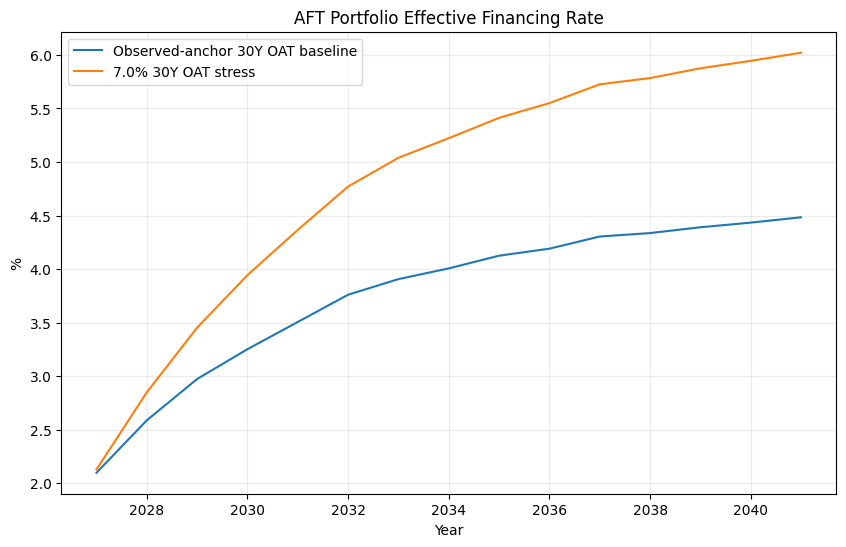

In [249]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    aft_baseline_path["year"],
    aft_baseline_path["effective_financing_rate"] * 100,
    label="Observed-anchor 30Y OAT baseline",
)

ax.plot(
    aft_stress_path["year"],
    aft_stress_path["effective_financing_rate"] * 100,
    label="7.0% 30Y OAT stress",
)

ax.set_title("AFT Portfolio Effective Financing Rate")
ax.set_xlabel("Year")
ax.set_ylabel("%")
ax.legend()
ax.grid(alpha=0.25)

plt.show()

## 4. Standalone deterministic AFT sensitivity

The 5.5% and 7.0% 30Y OAT scenarios above remain useful as standalone funding-cost sensitivities.

They are **not** the reference scenario for the stochastic bridge. The stochastic bridge later compares the stochastic AFT path against a separate time-varying **central AFT path**.

In [250]:
aft_comparison[
    [
        "year",
        "baseline_effective_rate",
        "stress_effective_rate",
        "interest_cost_shock_bn",
    ]
]

,year,baseline_effective_rate,stress_effective_rate,interest_cost_shock_bn
0,2027,0.020992,0.021304,0.913684
1,2028,0.025886,0.028498,7.682046
2,2029,0.029742,0.034541,15.138183
3,2030,0.032524,0.039439,23.557157
4,2031,0.035067,0.043661,31.861795
5,2032,0.037609,0.047705,40.930375
6,2033,0.039064,0.050391,50.368809
7,2034,0.040065,0.052218,59.478429
8,2035,0.041252,0.054118,69.403402
9,2036,0.041905,0.055495,80.640431


In [251]:
YEARS = aft_baseline_path["year"].astype(int).tolist()

assert YEARS == list(range(2027, 2042))

print("Simulation horizon:", YEARS[0], "to", YEARS[-1])

Simulation horizon: 2027 to 2041


# 5. Historical calibration dataset

The stochastic model is calibrated on annual observations from **1999–2025**.

Variables:

- French real GDP growth
- French HICP inflation
- French general-government primary balance / GDP
- German 10Y Bund yield
- France–Germany 10Y sovereign spread

In [252]:
ECB_CACHE_DIR = RAW_DIR / "ecb"

def create_ecb_session():
    retry_strategy = Retry(
        total=6,
        connect=6,
        read=6,
        status=6,
        backoff_factor=1.5,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=frozenset(["GET"]),
        respect_retry_after_header=True,
    )

    adapter = HTTPAdapter(max_retries=retry_strategy)
    session = requests.Session()
    session.mount("https://", adapter)
    session.mount("http://", adapter)

    session.headers.update({
        "Accept": "text/csv",
        "Accept-Encoding": "gzip, deflate",
        "User-Agent": "french-oat-model/1.0",
    })

    return session

ECB_SESSION = create_ecb_session()


def fetch_ecb_series(
    series_key,
    start_period="1999-01",
    end_period="2025-12",
    cache_dir=ECB_CACHE_DIR,
    force_refresh=False,
):
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    safe_key = (
        series_key
        .replace(".", "_")
        .replace("+", "_")
    )

    cache_path = (
        cache_dir
        / f"ecb_IRS_{safe_key}_{start_period}_{end_period}.csv"
    )

    if cache_path.exists() and not force_refresh:
        print(f"Loading cached ECB data:\n{cache_path}")
        return pd.read_csv(
            cache_path,
            parse_dates=["TIME_PERIOD"],
        )

    url = (
        "https://data-api.ecb.europa.eu/"
        f"service/data/IRS/{series_key}"
    )

    params = {
        "startPeriod": start_period,
        "endPeriod": end_period,
        "format": "csvdata",
        "detail": "dataonly",
    }

    response = ECB_SESSION.get(
        url,
        params=params,
        timeout=(10, 180),
    )
    response.raise_for_status()

    df = pd.read_csv(StringIO(response.text))

    required_columns = {"TIME_PERIOD", "OBS_VALUE"}
    missing = required_columns - set(df.columns)

    if missing:
        raise ValueError(
            f"ECB response missing columns: {missing}"
        )

    df["TIME_PERIOD"] = pd.to_datetime(
        df["TIME_PERIOD"],
        errors="coerce",
    )

    df["OBS_VALUE"] = pd.to_numeric(
        df["OBS_VALUE"],
        errors="coerce",
    )

    df = (
        df[["TIME_PERIOD", "OBS_VALUE"]]
        .dropna()
        .sort_values("TIME_PERIOD")
        .reset_index(drop=True)
    )

    df.to_csv(cache_path, index=False)
    return df

In [253]:
FRANCE_10Y_KEY = "M.FR.L.L40.CI.0000.EUR.N.Z"
GERMANY_10Y_KEY = "M.DE.L.L40.CI.0000.EUR.N.Z"

france_10y_monthly = fetch_ecb_series(
    FRANCE_10Y_KEY,
    start_period="1999-01",
    end_period="2025-12",
)

germany_10y_monthly = fetch_ecb_series(
    GERMANY_10Y_KEY,
    start_period="1999-01",
    end_period="2025-12",
)

def monthly_rate_to_annual(
    df,
    column_name,
):
    result = df.copy()
    result["year"] = result["TIME_PERIOD"].dt.year
    result[column_name] = (
        pd.to_numeric(
            result["OBS_VALUE"],
            errors="coerce",
        )
        / 100
    )

    return (
        result[["year", column_name]]
        .dropna()
        .groupby("year", as_index=False)[column_name]
        .mean()
    )

france_10y_annual = monthly_rate_to_annual(
    france_10y_monthly,
    "france_10y",
)

germany_10y_annual = monthly_rate_to_annual(
    germany_10y_monthly,
    "bund_10y",
)

rates_history = (
    france_10y_annual
    .merge(
        germany_10y_annual,
        on="year",
        how="inner",
        validate="one_to_one",
    )
)

rates_history["france_spread_10y"] = (
    rates_history["france_10y"]
    - rates_history["bund_10y"]
)

rates_history = (
    rates_history[
        rates_history["year"].between(1999, 2025)
    ]
    .sort_values("year")
    .reset_index(drop=True)
)

rates_history

Loading cached ECB data:
c:\Users\mikel\Desktop\french_oat_model\data\raw\ecb\ecb_IRS_M_FR_L_L40_CI_0000_EUR_N_Z_1999-01_2025-12.csv
Loading cached ECB data:
c:\Users\mikel\Desktop\french_oat_model\data\raw\ecb\ecb_IRS_M_DE_L_L40_CI_0000_EUR_N_Z_1999-01_2025-12.csv


,year,france_10y,bund_10y,france_spread_10y
0,1999,0.046192,0.044908,0.001283
1,2000,0.053942,0.052633,0.001308
2,2001,0.049392,0.047975,0.001417
3,2002,0.048600,0.047825,0.000775
4,2003,0.041300,0.040708,0.000592
5,2004,0.040983,0.040367,0.000617
6,2005,0.034100,0.033533,0.000567
7,2006,0.037967,0.037625,0.000342
8,2007,0.043042,0.042167,0.000875
9,2008,0.042342,0.039842,0.002500


In [254]:
EUROSTAT_CACHE_DIR = RAW_DIR / "eurostat"

def _jsonstat_category_labels(category_index):
    if isinstance(category_index, dict):
        return [
            label
            for label, _
            in sorted(
                category_index.items(),
                key=lambda x: x[1],
            )
        ]
    return list(category_index)


def fetch_eurostat_series(
    dataset_code,
    filters,
    value_name,
    cache_dir=EUROSTAT_CACHE_DIR,
    force_refresh=False,
):
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    filter_string = "_".join(
        f"{key}-{value}"
        for key, value
        in sorted(filters.items())
    )

    cache_path = (
        cache_dir
        / f"{dataset_code}_{filter_string}.csv"
    )

    if cache_path.exists() and not force_refresh:
        print(f"Loading cached Eurostat data:\n{cache_path}")
        return pd.read_csv(cache_path)

    url = (
        "https://ec.europa.eu/"
        "eurostat/api/dissemination/"
        "statistics/1.0/data/"
        f"{dataset_code}"
    )

    params = {
        "lang": "EN",
        **filters,
    }

    response = requests.get(
        url,
        params=params,
        timeout=(10, 180),
    )
    response.raise_for_status()
    data = response.json()

    dimension_ids = data["id"]
    dimension_sizes = data["size"]

    if "time" not in dimension_ids:
        raise ValueError(
            "Eurostat response contains no time dimension."
        )

    time_pos = dimension_ids.index("time")

    for i, dimension in enumerate(dimension_ids):
        if dimension != "time" and dimension_sizes[i] != 1:
            raise ValueError(
                f"Dimension {dimension!r} was not reduced to one category."
            )

    years = _jsonstat_category_labels(
        data["dimension"]["time"]["category"]["index"]
    )

    values = data["value"]
    rows = []

    for time_coordinate, year in enumerate(years):
        coordinates = [0 for _ in dimension_ids]
        coordinates[time_pos] = time_coordinate

        flat_index = int(
            np.ravel_multi_index(
                tuple(coordinates),
                tuple(dimension_sizes),
                order="C",
            )
        )

        if isinstance(values, dict):
            value = values.get(str(flat_index), np.nan)
        else:
            value = (
                values[flat_index]
                if flat_index < len(values)
                else np.nan
            )

        rows.append({
            "year": int(year),
            value_name: value,
        })

    result = pd.DataFrame(rows)
    result[value_name] = pd.to_numeric(
        result[value_name],
        errors="coerce",
    )

    result.to_csv(cache_path, index=False)
    return result

In [255]:
real_growth_history = fetch_eurostat_series(
    dataset_code="nama_10_gdp",
    filters={
        "freq": "A",
        "unit": "CLV_PCH_PRE",
        "na_item": "B1GQ",
        "geo": "FR",
    },
    value_name="real_growth",
)

real_growth_history["real_growth"] /= 100

real_growth_history = (
    real_growth_history[
        real_growth_history["year"].between(1999, 2025)
    ]
    .reset_index(drop=True)
)

inflation_history = fetch_eurostat_series(
    dataset_code="prc_hicp_aind",
    filters={
        "freq": "A",
        "unit": "RCH_A_AVG",
        "coicop": "CP00",
        "geo": "FR",
    },
    value_name="inflation",
)

inflation_history["inflation"] /= 100

inflation_history = (
    inflation_history[
        inflation_history["year"].between(1999, 2025)
    ]
    .reset_index(drop=True)
)

Loading cached Eurostat data:
c:\Users\mikel\Desktop\french_oat_model\data\raw\eurostat\nama_10_gdp_freq-A_geo-FR_na_item-B1GQ_unit-CLV_PCH_PRE.csv
Loading cached Eurostat data:
c:\Users\mikel\Desktop\french_oat_model\data\raw\eurostat\prc_hicp_aind_coicop-CP00_freq-A_geo-FR_unit-RCH_A_AVG.csv


In [256]:
DBNOMICS_CACHE_DIR = RAW_DIR / "ameco"

def fetch_ameco_primary_balance(
    cache_dir=DBNOMICS_CACHE_DIR,
    force_refresh=False,
):
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    cache_path = (
        cache_dir
        / "france_primary_balance_gdp.csv"
    )

    if cache_path.exists() and not force_refresh:
        print(f"Loading cached AMECO data:\n{cache_path}")
        return pd.read_csv(cache_path)

    series_code = "FRA.1.0.319.0.UBLGI"

    url = (
        "https://api.db.nomics.world/"
        "v22/series/"
        f"AMECO/UBLGI/{series_code}"
    )

    response = requests.get(
        url,
        params={"observations": 1},
        timeout=(10, 180),
    )
    response.raise_for_status()

    payload = response.json()

    docs = (
        payload
        .get("series", {})
        .get("docs", [])
    )

    if not docs:
        raise ValueError(
            "DBnomics returned no AMECO observations."
        )

    series = docs[0]

    result = pd.DataFrame({
        "year": pd.to_numeric(
            series["period"],
            errors="coerce",
        ),
        "primary_balance_gdp": pd.to_numeric(
            series["value"],
            errors="coerce",
        ),
    })

    result = result.dropna().copy()
    result["year"] = result["year"].astype(int)
    result["primary_balance_gdp"] /= 100

    result = (
        result[
            result["year"].between(1999, 2025)
        ]
        .reset_index(drop=True)
    )

    result.to_csv(cache_path, index=False)
    return result

primary_balance_history = (
    fetch_ameco_primary_balance()
)

Loading cached AMECO data:
c:\Users\mikel\Desktop\french_oat_model\data\raw\ameco\france_primary_balance_gdp.csv


In [257]:
macro_history = (
    real_growth_history
    .merge(
        inflation_history,
        on="year",
        how="inner",
    )
    .merge(
        primary_balance_history,
        on="year",
        how="inner",
    )
)

calibration_data = (
    macro_history
    .merge(
        rates_history[
            [
                "year",
                "bund_10y",
                "france_spread_10y",
            ]
        ],
        on="year",
        how="inner",
    )
)

CALIBRATION_START_YEAR = 1999
CALIBRATION_END_YEAR = 2025

CALIBRATION_VARIABLES = [
    "real_growth",
    "inflation",
    "primary_balance_gdp",
    "bund_10y",
    "france_spread_10y",
]

calibration_data = (
    calibration_data[
        calibration_data["year"].between(
            CALIBRATION_START_YEAR,
            CALIBRATION_END_YEAR,
        )
    ]
    .sort_values("year")
    .reset_index(drop=True)
)

expected_years = set(
    range(
        CALIBRATION_START_YEAR,
        CALIBRATION_END_YEAR + 1,
    )
)

missing_years = (
    expected_years
    - set(calibration_data["year"])
)

assert not missing_years, (
    f"Missing calibration years: {sorted(missing_years)}"
)

assert calibration_data["year"].is_unique

assert not (
    calibration_data[
        CALIBRATION_VARIABLES
    ]
    .isna()
    .any()
    .any()
)

assert len(calibration_data) == 27

print("Historical calibration dataset validation passed.")
calibration_data

Historical calibration dataset validation passed.


,year,real_growth,inflation,primary_balance_gdp,bund_10y,france_spread_10y
0,1999,0.034,0.006,0.015338,0.044908,0.001283
1,2000,0.041,0.018,0.016466,0.052633,0.001308
2,2001,0.019,0.018,0.016352,0.047975,0.001417
3,2002,0.011,0.019,-0.001475,0.047825,0.000775
4,2003,0.010,0.022,-0.012118,0.040708,0.000592
5,2004,0.029,0.023,-0.007540,0.040367,0.000617
6,2005,0.019,0.019,-0.007921,0.033533,0.000567
7,2006,0.027,0.019,-0.000543,0.037625,0.000342
8,2007,0.025,0.016,-0.003014,0.042167,0.000875
9,2008,0.004,0.032,-0.006292,0.039842,0.002500


## 6. AR(1) calibration and robust covariance

In [258]:
def estimate_ar1(
    series,
    variable_name,
):
    x = (
        pd.Series(series)
        .dropna()
        .astype(float)
        .to_numpy()
    )

    if len(x) < 10:
        raise ValueError(
            f"Too few observations for {variable_name}: {len(x)}"
        )

    y = x[1:]
    x_lag = x[:-1]

    X = np.column_stack([
        np.ones(len(x_lag)),
        x_lag,
    ])

    beta = np.linalg.lstsq(
        X,
        y,
        rcond=None,
    )[0]

    intercept = float(beta[0])
    rho = float(beta[1])

    fitted = (
        intercept
        + rho * x_lag
    )

    residuals = (
        y
        - fitted
    )

    degrees_of_freedom = len(residuals) - 2

    innovation_std = float(
        np.sqrt(
            np.sum(residuals ** 2)
            / degrees_of_freedom
        )
    )

    if abs(rho) < 1.0:
        long_run_mean = (
            intercept
            / (1.0 - rho)
        )
    else:
        long_run_mean = np.nan

    return {
        "variable": variable_name,
        "n_observations": len(x),
        "intercept": intercept,
        "rho": rho,
        "long_run_mean": long_run_mean,
        "innovation_std": innovation_std,
        "fitted": fitted,
        "residuals": residuals,
    }


ar1_results = {
    variable: estimate_ar1(
        calibration_data[variable],
        variable,
    )
    for variable
    in CALIBRATION_VARIABLES
}

ar1_summary = pd.DataFrame([
    {
        "variable": variable,
        "long_run_mean_pct": (
            result["long_run_mean"] * 100
        ),
        "rho": result["rho"],
        "innovation_std_pct": (
            result["innovation_std"] * 100
        ),
    }
    for variable, result
    in ar1_results.items()
])

ar1_summary.round(3)

,variable,long_run_mean_pct,rho,innovation_std_pct
0,real_growth,1.400,-0.242,2.393
1,inflation,1.891,0.460,1.258
2,primary_balance_gdp,-2.276,0.598,1.670
3,bund_10y,1.510,0.916,0.611
4,france_spread_10y,0.518,0.852,0.148


In [259]:
RESIDUAL_YEARS = (
    calibration_data["year"]
    .iloc[1:]
    .to_numpy()
)

residual_data = pd.DataFrame({
    variable:
        ar1_results[variable]["residuals"]
    for variable
    in CALIBRATION_VARIABLES
})

residual_data.insert(
    0,
    "year",
    RESIDUAL_YEARS,
)

RESIDUAL_MATRIX = (
    residual_data[
        CALIBRATION_VARIABLES
    ]
    .to_numpy(dtype=float)
)

raw_residual_correlation = (
    residual_data[
        CALIBRATION_VARIABLES
    ]
    .corr()
)

raw_residual_correlation.round(3)

,real_growth,inflation,primary_balance_gdp,bund_10y,france_spread_10y
real_growth,1.000,0.518,0.905,0.457,-0.005
inflation,0.518,1.000,0.406,0.604,0.200
primary_balance_gdp,0.905,0.406,1.000,0.297,-0.031
bund_10y,0.457,0.604,0.297,1.000,-0.035
france_spread_10y,-0.005,0.200,-0.031,-0.035,1.000


In [260]:
standardized_residuals = (
    residual_data[
        CALIBRATION_VARIABLES
    ]
    - residual_data[
        CALIBRATION_VARIABLES
    ].mean()
) / residual_data[
    CALIBRATION_VARIABLES
].std(ddof=1)

lw = LedoitWolf().fit(
    standardized_residuals.values
)

shrunk_covariance = lw.covariance_

std = np.sqrt(
    np.diag(shrunk_covariance)
)

CALIBRATED_CORRELATION_MATRIX = (
    shrunk_covariance
    / np.outer(std, std)
)

correlation_df = pd.DataFrame(
    CALIBRATED_CORRELATION_MATRIX,
    index=CALIBRATION_VARIABLES,
    columns=CALIBRATION_VARIABLES,
)

correlation_df.round(3)

,real_growth,inflation,primary_balance_gdp,bund_10y,france_spread_10y
real_growth,1.000,0.206,0.360,0.182,-0.002
inflation,0.206,1.000,0.162,0.241,0.080
primary_balance_gdp,0.360,0.162,1.000,0.118,-0.012
bund_10y,0.182,0.241,0.118,1.000,-0.014
france_spread_10y,-0.002,0.080,-0.012,-0.014,1.000


In [261]:
PERSISTENCE = {
    variable:
        ar1_results[variable]["rho"]
    for variable
    in CALIBRATION_VARIABLES
}

SHOCK_STD = {
    variable:
        ar1_results[variable]["innovation_std"]
    for variable
    in CALIBRATION_VARIABLES
}

shock_std_vector = np.array([
    SHOCK_STD[variable]
    for variable
    in CALIBRATION_VARIABLES
])

CALIBRATED_COVARIANCE_MATRIX = (
    np.outer(
        shock_std_vector,
        shock_std_vector,
    )
    * CALIBRATED_CORRELATION_MATRIX
)

assert (
    np.linalg.eigvalsh(
        CALIBRATED_COVARIANCE_MATRIX
    ) > 0
).all()

print(
    "Ledoit-Wolf covariance matrix is positive definite."
)

Ledoit-Wolf covariance matrix is positive definite.


In [262]:
# Preferred ordinary-times covariance:
# Minimum Covariance Determinant (robust to crisis outliers).

X = residual_data[
    CALIBRATION_VARIABLES
].to_numpy(dtype=float)

mcd = MinCovDet(
    random_state=RANDOM_SEED
).fit(X)

ROBUST_RESIDUAL_MEAN = (
    mcd.location_
)

ROBUST_COVARIANCE_MATRIX = (
    mcd.covariance_
)

robust_eigenvalues = (
    np.linalg.eigvalsh(
        ROBUST_COVARIANCE_MATRIX
    )
)

assert (
    robust_eigenvalues > 0
).all()

robust_std = np.sqrt(
    np.diag(
        ROBUST_COVARIANCE_MATRIX
    )
)

volatility_comparison = pd.DataFrame({
    "variable":
        CALIBRATION_VARIABLES,

    "full_sample_std_pct":
        [
            SHOCK_STD[x] * 100
            for x
            in CALIBRATION_VARIABLES
        ],

    "robust_std_pct":
        robust_std * 100,
})

volatility_comparison.round(3)

,variable,full_sample_std_pct,robust_std_pct
0,real_growth,2.393,1.018
1,inflation,1.258,0.614
2,primary_balance_gdp,1.670,0.747
3,bund_10y,0.611,0.502
4,france_spread_10y,0.148,0.070


In [263]:
robust_distance_squared = (
    mcd.mahalanobis(X)
)

OUTLIER_CONFIDENCE = 0.975

outlier_threshold = chi2.ppf(
    OUTLIER_CONFIDENCE,
    df=len(CALIBRATION_VARIABLES),
)

residual_diagnostics = (
    residual_data.copy()
)

residual_diagnostics[
    "robust_mahalanobis_sq"
] = robust_distance_squared

residual_diagnostics[
    "stress_observation"
] = (
    residual_diagnostics[
        "robust_mahalanobis_sq"
    ]
    > outlier_threshold
)

residual_diagnostics[
    [
        "year",
        "robust_mahalanobis_sq",
        "stress_observation",
    ]
].sort_values(
    "robust_mahalanobis_sq",
    ascending=False,
)

,year,robust_mahalanobis_sq,stress_observation
20,2020,169.551371,True
22,2022,68.183658,True
12,2012,65.818649,True
9,2009,55.669435,True
11,2011,46.621560,True
21,2021,40.889382,True
8,2008,34.523055,True
13,2013,30.704266,True
23,2023,29.645189,True
25,2025,24.242640,True


## 7. Time-varying central scenario

The central path is anchored to the IMF 2026 Article IV baseline through 2031:

- nominal GDP;
- real GDP growth;
- CPI;
- GDP deflator;
- primary balance;
- overall balance;
- public debt.

After 2031, macro/fiscal variables are held at transparent terminal assumptions. The market central path continues to follow the conditional expectation of the calibrated AR(1) processes.

The market path feeds the AFT refinancing engine; the IMF fiscal path validates the broader general-government DSA.

In [264]:
# Latest market state from 2026 ECB observations.

france_10y_current = fetch_ecb_series(
    FRANCE_10Y_KEY,
    start_period="2026-01",
    end_period="2026-10",
)

germany_10y_current = fetch_ecb_series(
    GERMANY_10Y_KEY,
    start_period="2026-01",
    end_period="2026-10",
)

latest_france_row = (
    france_10y_current
    .sort_values("TIME_PERIOD")
    .iloc[-1]
)

latest_germany_row = (
    germany_10y_current
    .sort_values("TIME_PERIOD")
    .iloc[-1]
)

CURRENT_FRANCE_10Y = (
    latest_france_row["OBS_VALUE"] / 100
)

CURRENT_BUND_10Y = (
    latest_germany_row["OBS_VALUE"] / 100
)

CURRENT_FRANCE_SPREAD_10Y = (
    CURRENT_FRANCE_10Y
    - CURRENT_BUND_10Y
)

print(f"France 10Y: {CURRENT_FRANCE_10Y:.2%}")
print(f"Bund 10Y: {CURRENT_BUND_10Y:.2%}")
print(f"France spread: {CURRENT_FRANCE_SPREAD_10Y:.2%}")

Loading cached ECB data:
c:\Users\mikel\Desktop\french_oat_model\data\raw\ecb\ecb_IRS_M_FR_L_L40_CI_0000_EUR_N_Z_2026-01_2026-10.csv
Loading cached ECB data:
c:\Users\mikel\Desktop\french_oat_model\data\raw\ecb\ecb_IRS_M_DE_L_L40_CI_0000_EUR_N_Z_2026-01_2026-10.csv
France 10Y: 4.00%
Bund 10Y: 3.19%
France spread: 0.81%


## Market-implied structural interest-rate regime

The historical AR(1) calibration remains useful for **persistence and shock dynamics**, but its
unconditional mean is strongly influenced by the post-GFC / negative-rate period.

We therefore separate:

\[
\text{historical dynamics}
\]

from

\[
\text{long-run rate regime}.
\]

The model keeps the historically estimated AR(1) persistence and innovation covariance, but
replaces the Bund's historical long-run mean with a **market-implied long-run anchor** derived
from the current German zero-coupon term structure published by the Deutsche Bundesbank.

The Bundesbank fits the German government curve using the Svensson method. We use the
10Y, 15Y, 20Y and 25Y zero-coupon rates to calculate two long-dated forward rates:

\[
f_{10,20}
=
\frac{20z_{20}-10z_{10}}{10}
\]

and

\[
f_{15,25}
=
\frac{25z_{25}-15z_{15}}{10}.
\]

Because the Svensson zero rates are treated as continuously compounded rates, these forward
relationships are additive in maturity-weighted rates.

The structural Bund anchor is the median of these two horizon-relevant forwards. The current
Svensson \(\beta_0\) parameter is also downloaded as a diagnostic because it is the asymptotic
long-run level of the fitted Svensson curve, but it is **not** used directly as the main anchor.

The France-Germany baseline spread retains its historical ordinary-times mean. Fiscal deterioration
is handled separately by Notebook 03's endogenous sovereign-risk feedback, avoiding double counting.

In [265]:
# ============================================================
# Market-implied long-run Bund anchor
# ============================================================

BUNDESBANK_API_BASE = (
    "https://api.statistiken.bundesbank.de/"
    "rest/data/BBSIS"
)

BUND_ZERO_KEYS = {
    10:
        "D.I.ZST.ZI.EUR.S1311.B.A604."
        "R10XX.R.A.A._Z._Z.A",
    15:
        "D.I.ZST.ZI.EUR.S1311.B.A604."
        "R15XX.R.A.A._Z._Z.A",
    20:
        "D.I.ZST.ZI.EUR.S1311.B.A604."
        "R20XX.R.A.A._Z._Z.A",
    25:
        "D.I.ZST.ZI.EUR.S1311.B.A604."
        "R25XX.R.A.A._Z._Z.A",
}

BUND_BETA0_KEY = (
    "D.I.ZST.B0.EUR.S1311.B.A604."
    "_Z.R.A.A._Z._Z.A"
)

BUND_MARKET_CACHE_DIR = (
    RAW_DIR
    / "bundesbank_market_anchor"
)

BUND_MARKET_CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


def _read_bundesbank_csv(
    content,
):
    last_error = None

    for encoding in [
        "utf-8-sig",
        "utf-8",
        "latin1",
    ]:
        try:
            return pd.read_csv(
                BytesIO(
                    content
                ),
                sep=None,
                engine="python",
                encoding=encoding,
            )
        except Exception as exc:
            last_error = exc

    raise ValueError(
        "Could not parse Bundesbank CSV response."
    ) from last_error


def _normalize_bundesbank_column(
    value,
):
    return (
        str(
            value
        )
        .strip()
        .lower()
        .replace(
            " ",
            "_",
        )
        .replace(
            "-",
            "_",
        )
    )


def fetch_bundesbank_series(
    series_key,
    value_name,
    *,
    force_refresh=False,
):
    safe_key = (
        series_key
        .replace(
            ".",
            "_",
        )
    )

    cache_path = (
        BUND_MARKET_CACHE_DIR
        / f"{safe_key}.csv"
    )

    if (
        cache_path.exists()
        and not force_refresh
    ):
        return pd.read_csv(
            cache_path,
            parse_dates=[
                "date"
            ],
        )

    url = (
        f"{BUNDESBANK_API_BASE}/"
        f"{series_key}"
    )

    response = (
        ECB_SESSION.get(
            url,
            params={
                "format":
                    "csv",
                "lang":
                    "en",
            },
            timeout=(
                10,
                180,
            ),
        )
    )

    response.raise_for_status()

    raw = (
        _read_bundesbank_csv(
            response.content
        )
    )

    normalized = {
        column:
            _normalize_bundesbank_column(
                column
            )
        for column
        in raw.columns
    }

    date_candidates = [
        column
        for column, name
        in normalized.items()
        if (
            "time_period" in name
            or name == "date"
            or "date" in name
            or "period" in name
        )
    ]

    if date_candidates:
        date_column = (
            date_candidates[0]
        )
    else:
        parse_scores = []

        for column in raw.columns:
            parsed = (
                pd.to_datetime(
                    raw[
                        column
                    ],
                    errors="coerce",
                    dayfirst=True,
                )
            )

            parse_scores.append(
                (
                    parsed
                    .notna()
                    .mean(),
                    column,
                )
            )

        parse_scores.sort(
            reverse=True
        )

        if (
            not parse_scores
            or parse_scores[0][0]
            < 0.50
        ):
            raise ValueError(
                "Could not identify Bundesbank date column."
            )

        date_column = (
            parse_scores[0][1]
        )

    value_candidates = [
        column
        for column, name
        in normalized.items()
        if (
            "obs_value" in name
            or name == "value"
            or name.endswith(
                "_value"
            )
        )
    ]

    if value_candidates:
        value_column = (
            value_candidates[0]
        )
    else:
        numeric_scores = []

        for column in raw.columns:
            if column == date_column:
                continue

            numeric = (
                pd.to_numeric(
                    raw[
                        column
                    ]
                    .astype(str)
                    .str.replace(
                        ",",
                        ".",
                        regex=False,
                    ),
                    errors="coerce",
                )
            )

            numeric_scores.append(
                (
                    numeric
                    .notna()
                    .sum(),
                    column,
                )
            )

        numeric_scores.sort(
            reverse=True
        )

        if not numeric_scores:
            raise ValueError(
                "Could not identify Bundesbank value column."
            )

        value_column = (
            numeric_scores[0][1]
        )

    values = (
        pd.to_numeric(
            raw[
                value_column
            ]
            .astype(str)
            .str.replace(
                ",",
                ".",
                regex=False,
            ),
            errors="coerce",
        )
        / 100
    )

    result = pd.DataFrame({
        "date":
            pd.to_datetime(
                raw[
                    date_column
                ],
                errors="coerce",
                dayfirst=True,
            ),

        value_name:
            values,
    })

    result = (
        result
        .dropna()
        .drop_duplicates(
            subset=[
                "date"
            ]
        )
        .sort_values(
            "date"
        )
        .reset_index(
            drop=True
        )
    )

    if result.empty:
        raise ValueError(
            f"No valid observations returned for {series_key}."
        )

    result.to_csv(
        cache_path,
        index=False,
    )

    return result


bund_zero_series = {}

for maturity, key in (
    BUND_ZERO_KEYS.items()
):
    bund_zero_series[
        maturity
    ] = (
        fetch_bundesbank_series(
            key,
            f"z{maturity}",
        )
    )

bund_beta0 = (
    fetch_bundesbank_series(
        BUND_BETA0_KEY,
        "beta0",
    )
)


bund_market_curve = (
    bund_zero_series[
        10
    ]
    .merge(
        bund_zero_series[
            15
        ],
        on="date",
        how="inner",
    )
    .merge(
        bund_zero_series[
            20
        ],
        on="date",
        how="inner",
    )
    .merge(
        bund_zero_series[
            25
        ],
        on="date",
        how="inner",
    )
    .merge(
        bund_beta0,
        on="date",
        how="inner",
    )
    .sort_values(
        "date"
    )
)

if bund_market_curve.empty:
    raise ValueError(
        "No common Bundesbank market date across "
        "the 10Y/15Y/20Y/25Y zero rates and Beta0."
    )

bund_market_latest = (
    bund_market_curve
    .iloc[
        -1
    ]
)

MARKET_ANCHOR_DATE = (
    pd.Timestamp(
        bund_market_latest[
            "date"
        ]
    )
)

BUND_ZERO_10Y = float(
    bund_market_latest[
        "z10"
    ]
)

BUND_ZERO_15Y = float(
    bund_market_latest[
        "z15"
    ]
)

BUND_ZERO_20Y = float(
    bund_market_latest[
        "z20"
    ]
)

BUND_ZERO_25Y = float(
    bund_market_latest[
        "z25"
    ]
)

BUND_SVENSSON_BETA0 = float(
    bund_market_latest[
        "beta0"
    ]
)


# Continuous-compounding forward rates implied by
# the fitted Bundesbank zero-coupon curve.
BUND_FORWARD_10Y10Y = (
    (
        20
        * BUND_ZERO_20Y
    )
    -
    (
        10
        * BUND_ZERO_10Y
    )
) / 10


BUND_FORWARD_15Y10Y = (
    (
        25
        * BUND_ZERO_25Y
    )
    -
    (
        15
        * BUND_ZERO_15Y
    )
) / 10


MARKET_IMPLIED_BUND_LONG_RUN = float(
    np.median(
        [
            BUND_FORWARD_10Y10Y,
            BUND_FORWARD_15Y10Y,
        ]
    )
)


HISTORICAL_BUND_LONG_RUN = float(
    ar1_results[
        "bund_10y"
    ][
        "long_run_mean"
    ]
)


# Structural regime parameter:
#   0.0 = historical AR(1) mean
#   1.0 = fully market-implied long-run regime
# Values in between form a transparent hybrid.
BUND_REGIME_WEIGHT = 1.0


SELECTED_BUND_LONG_RUN = (
    (
        1.0
        - BUND_REGIME_WEIGHT
    )
    * HISTORICAL_BUND_LONG_RUN
    +
    BUND_REGIME_WEIGHT
    * MARKET_IMPLIED_BUND_LONG_RUN
)


# Keep the baseline France sovereign spread centered
# on its historical ordinary-times mean. Notebook 03
# adds fiscal/debt sovereign feedback separately.
SELECTED_FRANCE_SPREAD_LONG_RUN = float(
    ar1_results[
        "france_spread_10y"
    ][
        "long_run_mean"
    ]
)


if not (
    0.0
    < MARKET_IMPLIED_BUND_LONG_RUN
    < 0.10
):
    raise ValueError(
        "Implausible market-implied Bund long-run anchor: "
        f"{MARKET_IMPLIED_BUND_LONG_RUN:.2%}"
    )


print(
    "Market anchor date:",
    MARKET_ANCHOR_DATE.date(),
)

print(
    "Historical Bund AR(1) long-run mean:",
    f"{HISTORICAL_BUND_LONG_RUN:.2%}",
)

print(
    "Bund 10Y10Y forward:",
    f"{BUND_FORWARD_10Y10Y:.2%}",
)

print(
    "Bund 15Y10Y forward:",
    f"{BUND_FORWARD_15Y10Y:.2%}",
)

print(
    "Svensson Beta0 diagnostic:",
    f"{BUND_SVENSSON_BETA0:.2%}",
)

print(
    "Selected structural Bund anchor:",
    f"{SELECTED_BUND_LONG_RUN:.2%}",
)

print(
    "Selected ordinary-times France spread anchor:",
    f"{SELECTED_FRANCE_SPREAD_LONG_RUN:.2%}",
)

C:\Users\mikel\AppData\Local\Temp\ipykernel_24372\2983341921.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
C:\Users\mikel\AppData\Local\Temp\ipykernel_24372\2983341921.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
C:\Users\mikel\AppData\Local\Temp\ipykernel_24372\2983341921.py:291: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
C:\Users\mikel\AppData\Local\Temp\ipykernel_24372\2983341921.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensur

Market anchor date: 2026-10-05
Historical Bund AR(1) long-run mean: 1.51%
Bund 10Y10Y forward: 4.11%
Bund 15Y10Y forward: 4.15%
Svensson Beta0 diagnostic: 4.15%
Selected structural Bund anchor: 4.13%
Selected ordinary-times France spread anchor: 0.52%


C:\Users\mikel\AppData\Local\Temp\ipykernel_24372\2983341921.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
C:\Users\mikel\AppData\Local\Temp\ipykernel_24372\2983341921.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
C:\Users\mikel\AppData\Local\Temp\ipykernel_24372\2983341921.py:291: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(


In [266]:
def build_ar1_expected_path(
    initial_value,
    long_run_mean,
    rho,
    years,
):
    previous = float(initial_value)
    result = {}

    for year in years:
        current = (
            long_run_mean
            + rho
            * (
                previous
                - long_run_mean
            )
        )

        result[year] = current
        previous = current

    return result


CENTRAL_START_YEAR = 2026
CENTRAL_END_YEAR = 2041

CENTRAL_YEARS = list(
    range(
        CENTRAL_START_YEAR,
        CENTRAL_END_YEAR + 1,
    )
)

SIMULATION_YEARS = list(
    range(
        2027,
        CENTRAL_END_YEAR + 1,
    )
)

bund_expected_historical = build_ar1_expected_path(
    initial_value=CURRENT_BUND_10Y,
    long_run_mean=(
        HISTORICAL_BUND_LONG_RUN
    ),
    rho=PERSISTENCE["bund_10y"],
    years=SIMULATION_YEARS,
)

bund_expected_regime = build_ar1_expected_path(
    initial_value=CURRENT_BUND_10Y,
    long_run_mean=(
        SELECTED_BUND_LONG_RUN
    ),
    rho=PERSISTENCE["bund_10y"],
    years=SIMULATION_YEARS,
)

# Selected central path used by the DSA.
bund_expected = (
    bund_expected_regime
)

spread_expected = build_ar1_expected_path(
    initial_value=CURRENT_FRANCE_SPREAD_10Y,
    long_run_mean=(
        SELECTED_FRANCE_SPREAD_LONG_RUN
    ),
    rho=PERSISTENCE[
        "france_spread_10y"
    ],
    years=SIMULATION_YEARS,
)

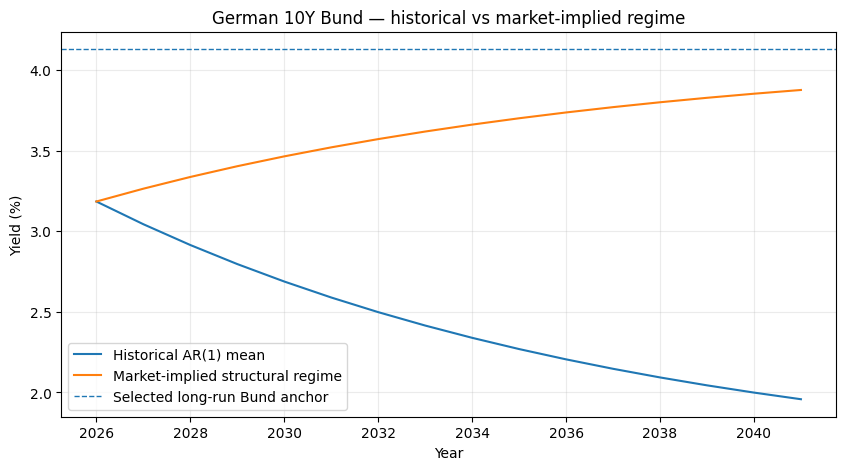

In [267]:
# ============================================================
# Historical vs market-implied Bund central path
# ============================================================

bund_regime_comparison = pd.DataFrame({
    "year":
        [
            2026,
            *SIMULATION_YEARS,
        ],

    "historical_mean_reversion":
        [
            CURRENT_BUND_10Y,
            *[
                bund_expected_historical[
                    year
                ]
                for year
                in SIMULATION_YEARS
            ],
        ],

    "market_regime_mean_reversion":
        [
            CURRENT_BUND_10Y,
            *[
                bund_expected_regime[
                    year
                ]
                for year
                in SIMULATION_YEARS
            ],
        ],
})


fig, ax = plt.subplots(
    figsize=(
        10,
        5,
    )
)

ax.plot(
    bund_regime_comparison[
        "year"
    ],
    bund_regime_comparison[
        "historical_mean_reversion"
    ]
    * 100,
    label=(
        "Historical AR(1) mean"
    ),
)

ax.plot(
    bund_regime_comparison[
        "year"
    ],
    bund_regime_comparison[
        "market_regime_mean_reversion"
    ]
    * 100,
    label=(
        "Market-implied structural regime"
    ),
)

ax.axhline(
    SELECTED_BUND_LONG_RUN
    * 100,
    linestyle="--",
    linewidth=1,
    label=(
        "Selected long-run Bund anchor"
    ),
)

ax.set_title(
    "German 10Y Bund — historical vs market-implied regime"
)

ax.set_xlabel(
    "Year"
)

ax.set_ylabel(
    "Yield (%)"
)

ax.grid(
    alpha=0.25
)

ax.legend()

plt.show()

In [268]:
# ============================================================
# IMF 2026 Article IV central macro/fiscal assumptions
# ============================================================

IMF_NOMINAL_GDP_BN = {
    2026: 3056,
    2027: 3137,
    2028: 3236,
    2029: 3334,
    2030: 3436,
    2031: 3537,
}

REAL_GROWTH_CENTRAL = {
    2026: 0.006,
    2027: 0.009,
    2028: 0.012,
    2029: 0.011,
    2030: 0.011,
    2031: 0.011,
}

# CPI is retained as the inflation proxy for linker indexation.
INFLATION_CENTRAL = {
    2026: 0.023,
    2027: 0.017,
    2028: 0.019,
    2029: 0.019,
    2030: 0.019,
    2031: 0.018,
}

# GDP deflator is used for nominal-GDP extrapolation after 2031.
GDP_DEFLATOR_CENTRAL = {
    2026: 0.015,
    2027: 0.017,
    2028: 0.019,
    2029: 0.019,
    2030: 0.019,
    2031: 0.018,
}

PRIMARY_BALANCE_CENTRAL = {
    2026: -0.027,
    2027: -0.023,
    2028: -0.017,
    2029: -0.011,
    2030: -0.006,
    2031: 0.000,
}

OVERALL_BALANCE_CENTRAL = {
    2026: -0.052,
    2027: -0.049,
    2028: -0.045,
    2029: -0.041,
    2030: -0.038,
    2031: -0.035,
}

IMF_PUBLIC_DEBT_GDP = {
    2026: 1.185,
    2027: 1.203,
    2028: 1.211,
    2029: 1.216,
    2030: 1.218,
    2031: 1.218,
}

# Interest expenditure / GDP = primary balance - overall balance.
CENTRAL_INTEREST_GDP_IMF = {
    year: (
        PRIMARY_BALANCE_CENTRAL[year]
        - OVERALL_BALANCE_CENTRAL[year]
    )
    for year in range(2026, 2032)
}

# Post-2031 values are terminal modelling assumptions, not forecasts.
TERMINAL_REAL_GROWTH = REAL_GROWTH_CENTRAL[2031]
TERMINAL_INFLATION = INFLATION_CENTRAL[2031]
TERMINAL_GDP_DEFLATOR = GDP_DEFLATOR_CENTRAL[2031]
TERMINAL_PRIMARY_BALANCE = PRIMARY_BALANCE_CENTRAL[2031]

for year in range(2032, CENTRAL_END_YEAR + 1):
    REAL_GROWTH_CENTRAL[year] = TERMINAL_REAL_GROWTH
    INFLATION_CENTRAL[year] = TERMINAL_INFLATION
    GDP_DEFLATOR_CENTRAL[year] = TERMINAL_GDP_DEFLATOR
    PRIMARY_BALANCE_CENTRAL[year] = TERMINAL_PRIMARY_BALANCE

In [269]:
# ============================================================
# Assemble central path
# ============================================================

central_path = pd.DataFrame({
    "year": CENTRAL_YEARS,
})

central_path["real_growth"] = (
    central_path["year"].map(REAL_GROWTH_CENTRAL)
)

central_path["inflation"] = (
    central_path["year"].map(INFLATION_CENTRAL)
)

central_path["gdp_deflator"] = (
    central_path["year"].map(GDP_DEFLATOR_CENTRAL)
)

central_path["primary_balance_gdp"] = (
    central_path["year"].map(PRIMARY_BALANCE_CENTRAL)
)

# ------------------------------------------------------------
# Nominal GDP: exact IMF levels through 2031
# ------------------------------------------------------------

central_path["nominal_gdp_eur"] = np.nan

for year, gdp_bn in IMF_NOMINAL_GDP_BN.items():
    central_path.loc[
        central_path["year"] == year,
        "nominal_gdp_eur",
    ] = gdp_bn * 1e9

# Post-2031 nominal GDP from real growth + GDP deflator.
for year in range(2032, CENTRAL_END_YEAR + 1):
    previous_gdp = float(
        central_path.loc[
            central_path["year"] == year - 1,
            "nominal_gdp_eur",
        ].iloc[0]
    )

    nominal_growth = (
        (1 + REAL_GROWTH_CENTRAL[year])
        * (1 + GDP_DEFLATOR_CENTRAL[year])
        - 1
    )

    central_path.loc[
        central_path["year"] == year,
        "nominal_gdp_eur",
    ] = previous_gdp * (1 + nominal_growth)

central_path["nominal_growth"] = (
    central_path["nominal_gdp_eur"].pct_change()
)

central_path.loc[
    central_path["year"] == 2026,
    "nominal_growth",
] = (
    (1 + REAL_GROWTH_CENTRAL[2026])
    * (1 + GDP_DEFLATOR_CENTRAL[2026])
    - 1
)

# ------------------------------------------------------------
# Market central path
# ------------------------------------------------------------

bund_central = {
    2026: CURRENT_BUND_10Y,
    **bund_expected,
}

spread_central = {
    2026: CURRENT_FRANCE_SPREAD_10Y,
    **spread_expected,
}

central_path["bund_10y"] = (
    central_path["year"].map(bund_central)
)

central_path["france_spread_10y"] = (
    central_path["year"].map(spread_central)
)

central_path["france_10y"] = (
    central_path["bund_10y"]
    + central_path["france_spread_10y"]
)

INITIAL_10S30S_SLOPE = (
    BASELINE_OAT_30Y
    - CURRENT_FRANCE_10Y
)

central_path["oat_30y"] = (
    central_path["france_10y"]
    + INITIAL_10S30S_SLOPE
)

central_path["interest_gdp_imf"] = (
    central_path["year"].map(CENTRAL_INTEREST_GDP_IMF)
)

required_central_columns = [
    "real_growth",
    "inflation",
    "gdp_deflator",
    "primary_balance_gdp",
    "nominal_gdp_eur",
    "nominal_growth",
    "bund_10y",
    "france_spread_10y",
    "france_10y",
    "oat_30y",
]

assert not (
    central_path[
        required_central_columns
    ]
    .isna()
    .any()
    .any()
)

assert np.allclose(
    central_path["france_10y"],
    central_path["bund_10y"]
    + central_path["france_spread_10y"],
)

print("Central path validation passed.")
central_path

central_oat_2026 = float(
    central_path.loc[
        central_path[
            "year"
        ]
        == 2026,
        "oat_30y",
    ]
    .iloc[
        0
    ]
)

assert np.isclose(
    central_oat_2026,
    CURRENT_OAT_30Y,
    atol=1e-12,
)

print(
    "2026 observed 30Y OAT anchor validation passed:",
    f"{central_oat_2026:.2%}",
)

Central path validation passed.
2026 observed 30Y OAT anchor validation passed: 5.17%


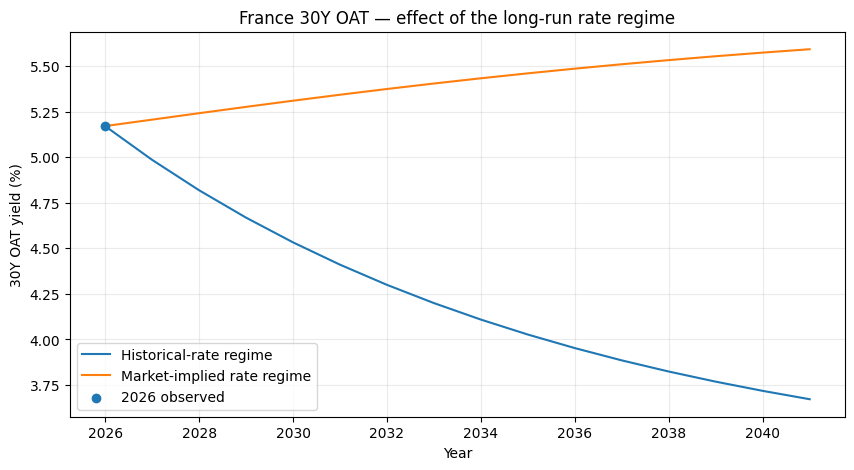

In [270]:
# ============================================================
# 30Y OAT: historical-mean vs market-regime central path
# ============================================================

historical_bund_central = {
    2026:
        CURRENT_BUND_10Y,
    **bund_expected_historical,
}

market_regime_oat_comparison = (
    central_path[
        [
            "year",
            "france_spread_10y",
            "oat_30y",
        ]
    ]
    .copy()
)

market_regime_oat_comparison[
    "bund_10y_historical"
] = (
    market_regime_oat_comparison[
        "year"
    ]
    .map(
        historical_bund_central
    )
)

market_regime_oat_comparison[
    "oat_30y_historical_mean"
] = (
    market_regime_oat_comparison[
        "bund_10y_historical"
    ]
    +
    market_regime_oat_comparison[
        "france_spread_10y"
    ]
    +
    INITIAL_10S30S_SLOPE
)


fig, ax = plt.subplots(
    figsize=(
        10,
        5,
    )
)

ax.plot(
    market_regime_oat_comparison[
        "year"
    ],
    market_regime_oat_comparison[
        "oat_30y_historical_mean"
    ]
    * 100,
    label=(
        "Historical-rate regime"
    ),
)

ax.plot(
    market_regime_oat_comparison[
        "year"
    ],
    market_regime_oat_comparison[
        "oat_30y"
    ]
    * 100,
    label=(
        "Market-implied rate regime"
    ),
)

ax.scatter(
    [
        CURRENT_YEAR
    ],
    [
        CURRENT_OAT_30Y
        * 100
    ],
    zorder=5,
    label=(
        "2026 observed"
    ),
)

ax.set_title(
    "France 30Y OAT — effect of the long-run rate regime"
)

ax.set_xlabel(
    "Year"
)

ax.set_ylabel(
    "30Y OAT yield (%)"
)

ax.grid(
    alpha=0.25
)

ax.legend()

plt.show()

## 8. Robust stochastic path

In [271]:
def draw_empirical_innovation(
    rng,
):
    index = rng.integers(
        low=0,
        high=len(
            RESIDUAL_MATRIX
        ),
    )

    return (
        RESIDUAL_MATRIX[
            index
        ].copy()
    )


def generate_calibrated_stochastic_path(
    central_path,
    rng,
    innovation_method="robust_gaussian",
):
    central = (
        central_path
        .set_index("year")
        .copy()
    )

    years = [
        year
        for year in central.index
        if year >= 2027
    ]

    previous = {
        variable:
            float(
                central.loc[
                    2026,
                    variable,
                ]
            )
        for variable
        in CALIBRATION_VARIABLES
    }

    rows = []

    for year in years:
        previous_year = year - 1

        if innovation_method == "robust_gaussian":
            shocks = rng.multivariate_normal(
                mean=np.zeros(len(CALIBRATION_VARIABLES)),
                cov=ROBUST_COVARIANCE_MATRIX,
            )

        elif innovation_method == "gaussian":
            shocks = rng.multivariate_normal(
                mean=np.zeros(
                    len(
                        CALIBRATION_VARIABLES
                    )
                ),
                cov=CALIBRATED_COVARIANCE_MATRIX,
            )

        elif innovation_method == "bootstrap":
            shocks = (
                draw_empirical_innovation(
                    rng
                )
            )

        else:
            raise ValueError(
                "innovation_method must be "
                "'robust_gaussian', 'gaussian', or 'bootstrap'."
            )

        current = {}

        for i, variable in enumerate(
            CALIBRATION_VARIABLES
        ):
            mu_t = float(
                central.loc[
                    year,
                    variable,
                ]
            )

            mu_previous = float(
                central.loc[
                    previous_year,
                    variable,
                ]
            )

            rho = PERSISTENCE[
                variable
            ]

            current[
                variable
            ] = (
                mu_t
                +
                rho
                * (
                    previous[
                        variable
                    ]
                    - mu_previous
                )
                +
                shocks[i]
            )

        france_10y = (
            current[
                "bund_10y"
            ]
            +
            current[
                "france_spread_10y"
            ]
        )

        oat_30y = (
            france_10y
            +
            INITIAL_10S30S_SLOPE
        )

        nominal_growth = (
            (
                1
                + current[
                    "real_growth"
                ]
            )
            *
            (
                1
                + current[
                    "inflation"
                ]
            )
            - 1
        )

        rows.append({
            "year": year,
            **current,
            "france_10y": france_10y,
            "oat_30y": oat_30y,
            "nominal_growth": nominal_growth,
        })

        previous = current

    return pd.DataFrame(rows)

In [272]:
rng = np.random.default_rng(
    RANDOM_SEED
)

stochastic_path = (
    generate_calibrated_stochastic_path(
        central_path=central_path,
        rng=rng,
        innovation_method="robust_gaussian",
    )
)

stochastic_path

,year,real_growth,inflation,primary_balance_gdp,bund_10y,france_spread_10y,france_10y,oat_30y,nominal_growth
0,2027,0.007599,0.020953,-0.030084,0.031927,0.006793,0.038720,0.050420,0.028712
1,2028,0.024758,0.024452,-0.011708,0.037035,0.005953,0.042988,0.054688,0.049815
2,2029,0.001457,0.015203,-0.013199,0.030832,0.006315,0.037147,0.048847,0.016682
3,2030,0.021478,0.019423,0.001461,0.030762,0.005897,0.036659,0.048359,0.041319
4,2031,0.011717,0.020795,0.000243,0.035883,0.005883,0.041765,0.053465,0.032756
5,2032,0.015983,0.017346,0.001616,0.037004,0.006254,0.043258,0.054958,0.033606
6,2033,-0.013733,0.013582,-0.010706,0.030225,0.006159,0.036384,0.048084,-0.000337
7,2034,0.003129,0.013781,-0.010034,0.027010,0.006015,0.033025,0.044725,0.016953
8,2035,0.005129,0.011856,-0.007590,0.022914,0.005801,0.028714,0.040414,0.017047
9,2036,0.012332,0.010007,-0.005823,0.021694,0.005977,0.027670,0.039370,0.022463


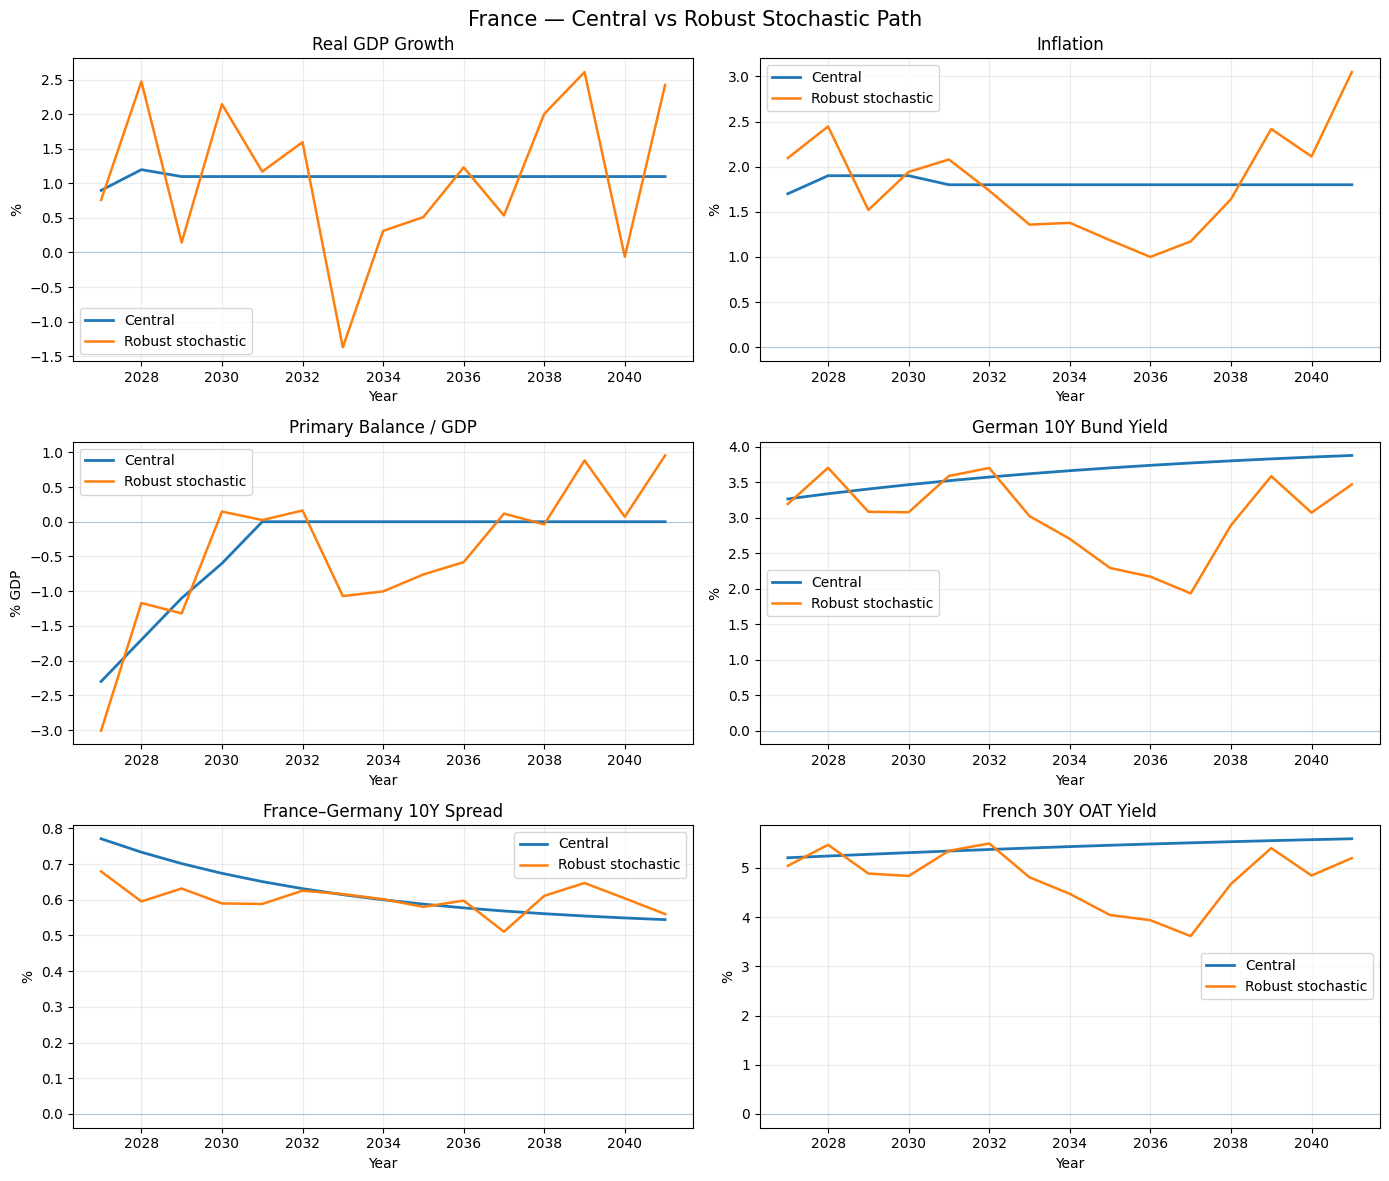

In [273]:
central_plot = (
    central_path[
        central_path["year"] >= 2027
    ]
    .copy()
    .reset_index(drop=True)
)

plot_specs = [
    ("real_growth", "Real GDP Growth", "%"),
    ("inflation", "Inflation", "%"),
    ("primary_balance_gdp", "Primary Balance / GDP", "% GDP"),
    ("bund_10y", "German 10Y Bund Yield", "%"),
    ("france_spread_10y", "France–Germany 10Y Spread", "%"),
    ("oat_30y", "French 30Y OAT Yield", "%"),
]

fig, axes = plt.subplots(
    3,
    2,
    figsize=(14, 12),
)

axes = axes.flatten()

for ax, (
    column,
    title,
    ylabel,
) in zip(
    axes,
    plot_specs,
):
    ax.plot(
        central_plot["year"],
        central_plot[column] * 100,
        label="Central",
        linewidth=2,
    )

    ax.plot(
        stochastic_path["year"],
        stochastic_path[column] * 100,
        label="Robust stochastic",
        linewidth=1.8,
    )

    ax.axhline(
        0,
        linewidth=0.8,
        alpha=0.3,
    )

    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.legend()

fig.suptitle(
    "France — Central vs Robust Stochastic Path",
    fontsize=15,
)

plt.tight_layout()
plt.show()

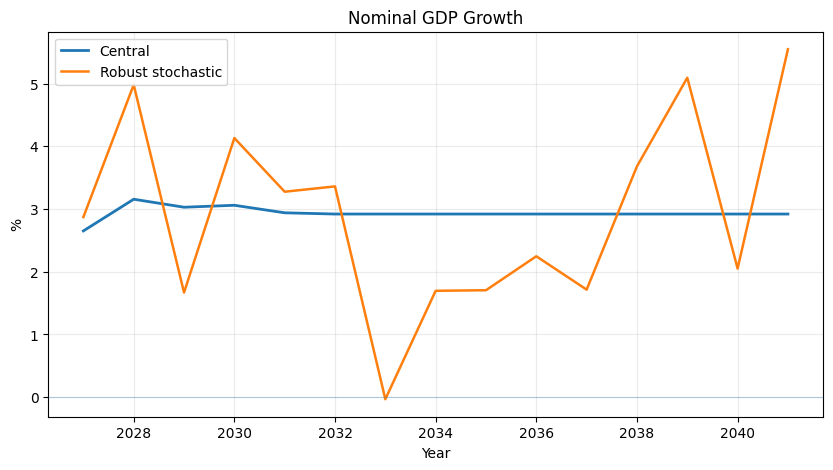

In [274]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    central_plot["year"],
    central_plot["nominal_growth"] * 100,
    label="Central",
    linewidth=2,
)

ax.plot(
    stochastic_path["year"],
    stochastic_path["nominal_growth"] * 100,
    label="Robust stochastic",
    linewidth=1.8,
)

ax.axhline(
    0,
    linewidth=0.8,
    alpha=0.3,
)

ax.set_title("Nominal GDP Growth")
ax.set_xlabel("Year")
ax.set_ylabel("%")
ax.grid(alpha=0.25)
ax.legend()

plt.show()

## 9. Corrected AFT → general-government bridge

The stochastic AFT path is now compared against the **central AFT path**, not against the old 5.5%-forever sensitivity.

The central general-government path is validated against the IMF debt baseline through 2031.

After 2031, the central GG effective interest rate evolves with changes in the central AFT effective financing rate, scaled by the AFT share of the starting GG debt stock.

The stochastic GG interest bill is:

\[
IC_t^{GG,stochastic}
=
i_t^{GG,central}
D_{t-1}^{GG,stochastic}
+
\Delta IC_t^{AFT}
\]

where:

\[
\Delta IC_t^{AFT}
=
IC_t^{AFT,stochastic}
-
IC_t^{AFT,central}
\]

This removes the reference-scenario mismatch that previously generated negative interest expenditure.

In [275]:
def build_market_curves_from_path(
    path,
):
    """
    Translate a path containing oat_30y into annual nominal
    and real issuance curves.

    The real-curve transmission remains a first-pass modelling
    assumption: real curves shift by the same amount as the
    30Y nominal OAT relative to the observed 2026 5.17% reference anchor.
    """
    result = {}

    for _, row in path.iterrows():
        year = int(row["year"])
        oat_30y = float(row["oat_30y"])

        nominal_curve = curve_from_30y_anchor(
            oat_30y_yield=oat_30y,
            offsets_to_30y=NOMINAL_CURVE_OFFSETS_TO_30Y,
        )

        yield_shift = (
            oat_30y
            - BASELINE_OAT_30Y
        )

        real_euro_curve = {
            maturity:
                rate + yield_shift
            for maturity, rate
            in baseline_real_euro_curve.items()
        }

        real_fr_curve = {
            maturity:
                rate + yield_shift
            for maturity, rate
            in baseline_real_fr_curve.items()
        }

        result[year] = {
            "nominal": nominal_curve,
            "real_euro": real_euro_curve,
            "real_fr": real_fr_curve,
        }

    return result


central_simulation_path = (
    central_path[
        central_path["year"] >= 2027
    ]
    .copy()
)

stochastic_simulation_path = (
    stochastic_path.copy()
)

central_market_curves = (
    build_market_curves_from_path(
        central_simulation_path
    )
)

stochastic_market_curves = (
    build_market_curves_from_path(
        stochastic_simulation_path
    )
)

In [276]:
# ============================================================
# Run central and stochastic AFT portfolios
# ============================================================

central_indexed = (
    central_simulation_path.set_index("year")
)

stochastic_indexed = (
    stochastic_simulation_path.set_index("year")
)

aft_central_path, aft_central_final = (
    simulate_portfolio_path(
        initial_portfolio=portfolio,
        initial_gdp_eur=BASELINE["initial_gdp_eur"],
        start_year=BASELINE["start_year"],
        years=BASELINE["horizon_years"],
        nominal_growth=(
            central_indexed[
                "nominal_growth"
            ].to_dict()
        ),
        primary_balance_ratio=(
            central_indexed[
                "primary_balance_gdp"
            ].to_dict()
        ),
        market_curves=central_market_curves,
        issuance_plan=ISSUANCE_PLAN,
        french_inflation=(
            central_indexed[
                "inflation"
            ].to_dict()
        ),
        euro_inflation=(
            central_indexed[
                "inflation"
            ].to_dict()
        ),
    )
)

aft_stochastic_path, aft_stochastic_final = (
    simulate_portfolio_path(
        initial_portfolio=portfolio,
        initial_gdp_eur=BASELINE["initial_gdp_eur"],
        start_year=BASELINE["start_year"],
        years=BASELINE["horizon_years"],
        nominal_growth=(
            stochastic_indexed[
                "nominal_growth"
            ].to_dict()
        ),
        primary_balance_ratio=(
            stochastic_indexed[
                "primary_balance_gdp"
            ].to_dict()
        ),
        market_curves=stochastic_market_curves,
        issuance_plan=ISSUANCE_PLAN,
        french_inflation=(
            stochastic_indexed[
                "inflation"
            ].to_dict()
        ),
        euro_inflation=(
            stochastic_indexed[
                "inflation"
            ].to_dict()
        ),
    )
)

stochastic_aft_cost_shock = pd.Series(
    (
        aft_stochastic_path[
            "total_financing_cost_eur"
        ].to_numpy()
        -
        aft_central_path[
            "total_financing_cost_eur"
        ].to_numpy()
    ),
    index=YEARS,
    name="aft_cost_shock_eur",
)

aft_bridge_diagnostic = pd.DataFrame({
    "year": YEARS,
    "central_aft_cost_bn": (
        aft_central_path[
            "total_financing_cost_eur"
        ].to_numpy()
        / 1e9
    ),
    "stochastic_aft_cost_bn": (
        aft_stochastic_path[
            "total_financing_cost_eur"
        ].to_numpy()
        / 1e9
    ),
    "aft_cost_shock_bn": (
        stochastic_aft_cost_shock.to_numpy()
        / 1e9
    ),
})

aft_bridge_diagnostic

,year,central_aft_cost_bn,stochastic_aft_cost_bn,aft_cost_shock_bn
0,2027,61.438545,62.709027,1.270482
1,2028,76.105300,78.224543,2.119244
2,2029,91.092488,90.134125,-0.958362
3,2030,103.617088,102.544627,-1.072461
4,2031,115.687018,112.912657,-2.774361
5,2032,128.792396,124.732948,-4.059448
6,2033,139.308721,134.004657,-5.304064
7,2034,148.959645,142.252611,-6.707035
8,2035,160.388729,149.880950,-10.507780
9,2036,170.521588,153.984537,-16.537051


In [277]:
# ============================================================
# Build IMF-consistent central general-government path
# ============================================================

AFT_SHARE_OF_INITIAL_GG_DEBT = min(
    1.0,
    total_debt(portfolio)
    / INITIAL_GG_DEBT_EUR,
)

print(
    f"AFT indexed debt / initial GG debt: "
    f"{AFT_SHARE_OF_INITIAL_GG_DEBT:.1%}"
)


def build_central_gg_path(
    central_path,
    aft_central_path,
):
    """
    2027–2031:
        Use IMF nominal GDP, primary balance and implied
        interest/GDP directly.

    2032 onward:
        Keep the central macro/fiscal path and evolve the
        GG effective interest rate with changes in the central
        AFT effective financing rate, scaled by the AFT share
        of the initial GG debt stock.
    """

    central = central_path.set_index("year")
    aft = aft_central_path.set_index("year")

    debt = INITIAL_GG_DEBT_EUR
    previous_effective_rate = None
    rows = []

    for year in YEARS:
        gdp_end = float(
            central.loc[
                year,
                "nominal_gdp_eur",
            ]
        )

        pb_ratio = float(
            central.loc[
                year,
                "primary_balance_gdp",
            ]
        )

        pb_eur = (
            pb_ratio
            * gdp_end
        )

        if year <= 2031:
            interest_gdp = float(
                central.loc[
                    year,
                    "interest_gdp_imf",
                ]
            )

            interest_eur = (
                interest_gdp
                * gdp_end
            )

            effective_rate = (
                interest_eur
                / debt
            )

        else:
            aft_rate_change = (
                float(
                    aft.loc[
                        year,
                        "effective_financing_rate",
                    ]
                )
                -
                float(
                    aft.loc[
                        year - 1,
                        "effective_financing_rate",
                    ]
                )
            )

            effective_rate = (
                previous_effective_rate
                +
                AFT_SHARE_OF_INITIAL_GG_DEBT
                * aft_rate_change
            )

            if effective_rate <= 0:
                raise ValueError(
                    f"Central GG effective rate became "
                    f"non-positive in {year}: "
                    f"{effective_rate:.4%}"
                )

            interest_eur = (
                effective_rate
                * debt
            )

            interest_gdp = (
                interest_eur
                / gdp_end
            )

        debt_end = (
            debt
            + interest_eur
            - pb_eur
        )

        rows.append({
            "year": year,
            "gdp_end_eur": gdp_end,
            "debt_start_eur": debt,
            "primary_balance_gdp": pb_ratio,
            "primary_balance_eur": pb_eur,
            "interest_eur": interest_eur,
            "interest_gdp": interest_gdp,
            "effective_interest_rate": effective_rate,
            "debt_end_eur": debt_end,
            "debt_gdp_end": (
                debt_end
                / gdp_end
            ),
        })

        debt = debt_end
        previous_effective_rate = effective_rate

    return pd.DataFrame(rows)


gg_central_path = (
    build_central_gg_path(
        central_path=central_path,
        aft_central_path=aft_central_path,
    )
)


# ============================================================
# Validate central GG path against IMF through 2031
# ============================================================

imf_validation = (
    gg_central_path[
        gg_central_path["year"] <= 2031
    ][
        [
            "year",
            "debt_gdp_end",
            "interest_gdp",
        ]
    ]
    .copy()
)

imf_validation["imf_debt_gdp"] = (
    imf_validation["year"]
    .map(IMF_PUBLIC_DEBT_GDP)
)

imf_validation["debt_error_pp"] = (
    (
        imf_validation[
            "debt_gdp_end"
        ]
        -
        imf_validation[
            "imf_debt_gdp"
        ]
    )
    * 100
)

print(
    imf_validation.to_string(
        index=False
    )
)

assert (
    imf_validation[
        "debt_error_pp"
    ]
    .abs()
    .max()
    < 0.15
), (
    "Central GG path does not reproduce the "
    "IMF debt baseline closely enough."
)

print("IMF central-path validation passed.")


# ============================================================
# Stochastic general-government DSA
# ============================================================

def simulate_stochastic_gg_dsa(
    stochastic_path,
    gg_central_path,
    aft_cost_shock,
):
    """
    Apply the central GG effective rate to the stochastic debt
    stock, then add only the incremental AFT financing-cost
    deviation from the central AFT path.
    """

    stochastic = stochastic_path.set_index("year")
    central_gg = gg_central_path.set_index("year")

    debt = INITIAL_GG_DEBT_EUR
    gdp = BASELINE["initial_gdp_eur"]

    rows = []

    for year in YEARS:
        nominal_growth = float(
            stochastic.loc[
                year,
                "nominal_growth",
            ]
        )

        gdp_end = (
            gdp
            * (1 + nominal_growth)
        )

        pb_ratio = float(
            stochastic.loc[
                year,
                "primary_balance_gdp",
            ]
        )

        pb_eur = (
            pb_ratio
            * gdp_end
        )

        central_effective_rate = float(
            central_gg.loc[
                year,
                "effective_interest_rate",
            ]
        )

        baseline_interest_on_stock = (
            central_effective_rate
            * debt
        )

        aft_shock_eur = float(
            aft_cost_shock.loc[year]
        )

        total_interest_eur = (
            baseline_interest_on_stock
            + aft_shock_eur
        )

        if total_interest_eur <= 0:
            raise ValueError(
                f"Negative/non-positive GG interest bill "
                f"in {year}: "
                f"€{total_interest_eur / 1e9:.2f}bn"
            )

        implied_effective_rate = (
            total_interest_eur
            / debt
        )

        debt_end = (
            debt
            + total_interest_eur
            - pb_eur
        )

        rows.append({
            "year": year,
            "gdp_start_eur": gdp,
            "gdp_end_eur": gdp_end,
            "nominal_growth": nominal_growth,
            "debt_start_eur": debt,
            "central_effective_rate": central_effective_rate,
            "aft_interest_cost_shock_eur": aft_shock_eur,
            "total_interest_eur": total_interest_eur,
            "implied_effective_rate": implied_effective_rate,
            "interest_gdp": (
                total_interest_eur
                / gdp_end
            ),
            "primary_balance_gdp": pb_ratio,
            "primary_balance_eur": pb_eur,
            "debt_end_eur": debt_end,
            "debt_gdp_end": (
                debt_end
                / gdp_end
            ),
        })

        gdp = gdp_end
        debt = debt_end

    return pd.DataFrame(rows)


gg_stochastic_path = (
    simulate_stochastic_gg_dsa(
        stochastic_path=stochastic_path,
        gg_central_path=gg_central_path,
        aft_cost_shock=stochastic_aft_cost_shock,
    )
)

gg_stochastic_path[
    [
        "year",
        "nominal_growth",
        "primary_balance_gdp",
        "central_effective_rate",
        "implied_effective_rate",
        "interest_gdp",
        "debt_gdp_end",
    ]
]

AFT indexed debt / initial GG debt: 80.9%
 year  debt_gdp_end  interest_gdp  imf_debt_gdp  debt_error_pp
 2027      1.203402         0.026         1.203       0.040230
 2028      1.211586         0.028         1.211       0.058622
 2029      1.216973         0.030         1.216       0.097271
 2030      1.218846         0.032         1.218       0.084604
 2031      1.219042         0.035         1.218       0.104156
IMF central-path validation passed.


,year,nominal_growth,primary_balance_gdp,central_effective_rate,implied_effective_rate,interest_gdp,debt_gdp_end
0,2027,0.028712,-0.030084,0.022522,0.022873,0.026348,1.208359
1,2028,0.049815,-0.011708,0.024002,0.024560,0.028269,1.190996
2,2029,0.016682,-0.013199,0.025511,0.025267,0.029599,1.214252
3,2030,0.041319,0.001461,0.027099,0.026836,0.031293,1.195903
4,2031,0.032756,0.000243,0.029560,0.028896,0.033461,1.191189
5,2032,0.033606,0.001616,0.031702,0.030758,0.035447,1.186291
6,2033,-0.000337,-0.010706,0.032993,0.031795,0.037731,1.235128
7,2034,0.016953,-0.010034,0.033910,0.032454,0.039416,1.263987
8,2035,0.017047,-0.007590,0.035050,0.032858,0.040836,1.291228
9,2036,0.022463,-0.005823,0.035743,0.032422,0.040944,1.309628


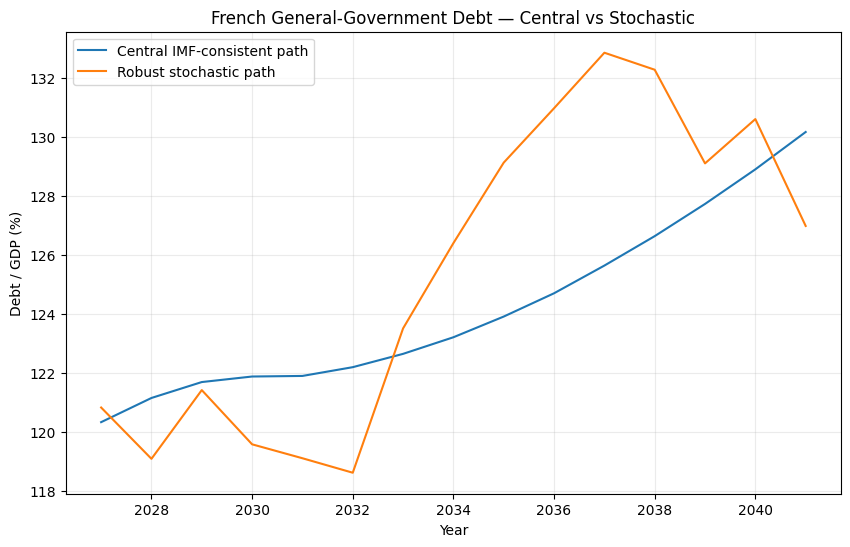

,year,central_debt_gdp,stochastic_debt_gdp,stochastic_nominal_growth,stochastic_primary_balance_gdp,stochastic_interest_gdp,aft_cost_shock_bn,debt_gap_pp
0,2027,120.34,120.84,2.87,-3.01,2.63,1.27,0.50
1,2028,121.16,119.10,4.98,-1.17,2.83,2.12,-2.06
2,2029,121.70,121.43,1.67,-1.32,2.96,-0.96,-0.27
3,2030,121.88,119.59,4.13,0.15,3.13,-1.07,-2.29
4,2031,121.90,119.12,3.28,0.02,3.35,-2.77,-2.79
5,2032,122.20,118.63,3.36,0.16,3.54,-4.06,-3.57
6,2033,122.65,123.51,-0.03,-1.07,3.77,-5.30,0.86
7,2034,123.21,126.40,1.70,-1.00,3.94,-6.71,3.19
8,2035,123.91,129.12,1.70,-0.76,4.08,-10.51,5.21
9,2036,124.70,130.96,2.25,-0.58,4.09,-16.54,6.26


In [278]:
# ============================================================
# Central vs stochastic GG debt
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    gg_central_path["year"],
    gg_central_path["debt_gdp_end"] * 100,
    label="Central IMF-consistent path",
)

ax.plot(
    gg_stochastic_path["year"],
    gg_stochastic_path["debt_gdp_end"] * 100,
    label="Robust stochastic path",
)

ax.set_title(
    "French General-Government Debt — Central vs Stochastic"
)

ax.set_xlabel("Year")
ax.set_ylabel("Debt / GDP (%)")
ax.legend()
ax.grid(alpha=0.25)

plt.show()


# ============================================================
# Accounting diagnostics
# ============================================================

debt_diagnostic = pd.DataFrame({
    "year": YEARS,
    "central_debt_gdp": (
        gg_central_path[
            "debt_gdp_end"
        ].to_numpy()
    ),
    "stochastic_debt_gdp": (
        gg_stochastic_path[
            "debt_gdp_end"
        ].to_numpy()
    ),
    "stochastic_nominal_growth": (
        gg_stochastic_path[
            "nominal_growth"
        ].to_numpy()
    ),
    "stochastic_primary_balance_gdp": (
        gg_stochastic_path[
            "primary_balance_gdp"
        ].to_numpy()
    ),
    "stochastic_interest_gdp": (
        gg_stochastic_path[
            "interest_gdp"
        ].to_numpy()
    ),
    "aft_cost_shock_bn": (
        stochastic_aft_cost_shock.to_numpy()
        / 1e9
    ),
})

debt_diagnostic["debt_gap_pp"] = (
    (
        debt_diagnostic[
            "stochastic_debt_gdp"
        ]
        -
        debt_diagnostic[
            "central_debt_gdp"
        ]
    )
    * 100
)

display_diag = debt_diagnostic.copy()

for col in [
    "central_debt_gdp",
    "stochastic_debt_gdp",
    "stochastic_nominal_growth",
    "stochastic_primary_balance_gdp",
    "stochastic_interest_gdp",
]:
    display_diag[col] *= 100

display_diag.round(2)

# Current stopping point

This corrected version fixes the reference-scenario mismatch that previously drove general-government interest expenditure below zero.

The model now has:

- an IMF-consistent 2026 starting point;
- exact IMF nominal GDP, fiscal balance, primary balance and debt targets through 2031;
- nominal GDP growth based on the IMF nominal-GDP path rather than HICP;
- a central AFT refinancing path;
- a robust stochastic AFT path;
- AFT financing-cost shocks measured **relative to the central AFT path**;
- a central GG debt path validated against IMF 2027–2031 debt ratios;
- post-2031 central GG interest-rate evolution linked to central AFT repricing;
- stochastic GG interest costs that preserve debt-stock feedback;
- a hard failure if the model ever produces a non-positive general-government interest bill.

The next stage is to validate the corrected single stochastic path and then scale the model to Monte Carlo.

# 10. Monte Carlo simulation

The single-path model has passed its accounting and zero-shock validation checks. We can now propagate the calibrated ordinary-times uncertainty through the full model.

Each simulation performs:

\[
\text{macro/market shocks}
\rightarrow
\text{AFT portfolio}
\rightarrow
\Delta IC_t^{AFT}
\rightarrow
\text{general-government DSA}
\]

The AFT shock is always measured relative to `aft_central_path`:

\[
\Delta IC_t^{AFT}
=
IC_t^{AFT,sim}
-
IC_t^{AFT,central}
\]

The 5.5%-forever path remains only a standalone sensitivity and is never used as the Monte Carlo reference.

In [279]:
# ============================================================
# Monte Carlo configuration
# ============================================================

N_SIMULATIONS = 10_000
MONTE_CARLO_SEED = 20261003
INNOVATION_METHOD = "robust_gaussian"

# Quick pre-flight before the full 10,000-path run.
N_SMOKE_SIMULATIONS = 250

# Renamed standalone sensitivity path.
aft_55_sensitivity_path = (
    aft_baseline_path
)

In [280]:
# ============================================================
# Monte Carlo engine
# ============================================================

def run_monte_carlo(
    n_simulations,
    seed,
    innovation_method="robust_gaussian",
    progress_every=500,
):
    """
    Run the complete stochastic DSA.

    Only compact NumPy arrays are retained; intermediate
    DataFrames are discarded immediately.
    """

    years_array = np.asarray(
        YEARS,
        dtype=int,
    )

    n_years = len(
        years_array
    )

    rng = np.random.default_rng(
        seed
    )

    results = {
        "real_growth": np.empty(
            (n_simulations, n_years),
            dtype=float,
        ),
        "inflation": np.empty(
            (n_simulations, n_years),
            dtype=float,
        ),
        "nominal_growth": np.empty(
            (n_simulations, n_years),
            dtype=float,
        ),
        "primary_balance_gdp": np.empty(
            (n_simulations, n_years),
            dtype=float,
        ),
        "bund_10y": np.empty(
            (n_simulations, n_years),
            dtype=float,
        ),
        "france_spread_10y": np.empty(
            (n_simulations, n_years),
            dtype=float,
        ),
        "oat_30y": np.empty(
            (n_simulations, n_years),
            dtype=float,
        ),
        "aft_effective_financing_rate": np.empty(
            (n_simulations, n_years),
            dtype=float,
        ),
        "aft_cost_shock_eur": np.empty(
            (n_simulations, n_years),
            dtype=float,
        ),
        "gg_effective_rate": np.empty(
            (n_simulations, n_years),
            dtype=float,
        ),
        "interest_gdp": np.empty(
            (n_simulations, n_years),
            dtype=float,
        ),
        "debt_gdp": np.empty(
            (n_simulations, n_years),
            dtype=float,
        ),
    }

    central_aft_cost = (
        aft_central_path[
            "total_financing_cost_eur"
        ]
        .to_numpy(
            dtype=float
        )
    )

    for simulation in range(
        n_simulations
    ):

        try:
            stochastic_simulation = (
                generate_calibrated_stochastic_path(
                    central_path=central_path,
                    rng=rng,
                    innovation_method=innovation_method,
                )
            )

            stochastic_indexed = (
                stochastic_simulation
                .set_index(
                    "year"
                )
            )

            market_curves = (
                build_market_curves_from_path(
                    stochastic_simulation
                )
            )

            aft_simulation, _ = (
                simulate_portfolio_path(
                    initial_portfolio=portfolio,
                    initial_gdp_eur=(
                        BASELINE[
                            "initial_gdp_eur"
                        ]
                    ),
                    start_year=(
                        BASELINE[
                            "start_year"
                        ]
                    ),
                    years=(
                        BASELINE[
                            "horizon_years"
                        ]
                    ),
                    nominal_growth=(
                        stochastic_indexed[
                            "nominal_growth"
                        ]
                        .to_dict()
                    ),
                    primary_balance_ratio=(
                        stochastic_indexed[
                            "primary_balance_gdp"
                        ]
                        .to_dict()
                    ),
                    market_curves=market_curves,
                    issuance_plan=ISSUANCE_PLAN,
                    french_inflation=(
                        stochastic_indexed[
                            "inflation"
                        ]
                        .to_dict()
                    ),
                    euro_inflation=(
                        stochastic_indexed[
                            "inflation"
                        ]
                        .to_dict()
                    ),
                )
            )

            aft_cost_shock = pd.Series(
                (
                    aft_simulation[
                        "total_financing_cost_eur"
                    ]
                    .to_numpy(
                        dtype=float
                    )
                    -
                    central_aft_cost
                ),
                index=YEARS,
            )

            gg_simulation = (
                simulate_stochastic_gg_dsa(
                    stochastic_path=stochastic_simulation,
                    gg_central_path=gg_central_path,
                    aft_cost_shock=aft_cost_shock,
                )
            )

        except Exception as exc:
            raise RuntimeError(
                "Monte Carlo simulation failed at "
                f"path {simulation + 1:,} of "
                f"{n_simulations:,}."
            ) from exc

        for variable in [
            "real_growth",
            "inflation",
            "nominal_growth",
            "primary_balance_gdp",
            "bund_10y",
            "france_spread_10y",
            "oat_30y",
        ]:
            results[
                variable
            ][
                simulation,
                :,
            ] = (
                stochastic_simulation[
                    variable
                ]
                .to_numpy(
                    dtype=float
                )
            )

        results[
            "aft_effective_financing_rate"
        ][
            simulation,
            :,
        ] = (
            aft_simulation[
                "effective_financing_rate"
            ]
            .to_numpy(
                dtype=float
            )
        )

        results[
            "aft_cost_shock_eur"
        ][
            simulation,
            :,
        ] = (
            aft_cost_shock
            .to_numpy(
                dtype=float
            )
        )

        results[
            "gg_effective_rate"
        ][
            simulation,
            :,
        ] = (
            gg_simulation[
                "implied_effective_rate"
            ]
            .to_numpy(
                dtype=float
            )
        )

        results[
            "interest_gdp"
        ][
            simulation,
            :,
        ] = (
            gg_simulation[
                "interest_gdp"
            ]
            .to_numpy(
                dtype=float
            )
        )

        results[
            "debt_gdp"
        ][
            simulation,
            :,
        ] = (
            gg_simulation[
                "debt_gdp_end"
            ]
            .to_numpy(
                dtype=float
            )
        )

        if (
            progress_every
            and (
                (simulation + 1)
                % progress_every
                == 0
            )
        ):
            print(
                f"Completed "
                f"{simulation + 1:,} / "
                f"{n_simulations:,}"
            )

    for name, values in (
        results.items()
    ):
        if not np.isfinite(
            values
        ).all():
            raise ValueError(
                f"Non-finite values found "
                f"in Monte Carlo output: "
                f"{name}"
            )

    return {
        "years": years_array,
        "n_simulations": n_simulations,
        "seed": seed,
        "innovation_method": innovation_method,
        **results,
    }

In [281]:
# ============================================================
# Pre-flight Monte Carlo validation
# ============================================================

mc_smoke = run_monte_carlo(
    n_simulations=N_SMOKE_SIMULATIONS,
    seed=MONTE_CARLO_SEED,
    innovation_method=INNOVATION_METHOD,
    progress_every=0,
)

assert (
    mc_smoke[
        "debt_gdp"
    ].shape
    ==
    (
        N_SMOKE_SIMULATIONS,
        len(YEARS),
    )
)

assert (
    mc_smoke[
        "interest_gdp"
    ] > 0
).all()

print(
    "Monte Carlo pre-flight passed:",
    mc_smoke[
        "debt_gdp"
    ].shape,
)

Monte Carlo pre-flight passed: (250, 15)


In [282]:
# ============================================================
# Full Monte Carlo simulation
# ============================================================

mc = run_monte_carlo(
    n_simulations=N_SIMULATIONS,
    seed=MONTE_CARLO_SEED,
    innovation_method=INNOVATION_METHOD,
    progress_every=500,
)

print(
    "Monte Carlo complete."
)

print(
    "Debt matrix shape:",
    mc[
        "debt_gdp"
    ].shape,
)

Completed 500 / 10,000
Completed 1,000 / 10,000
Completed 1,500 / 10,000
Completed 2,000 / 10,000
Completed 2,500 / 10,000
Completed 3,000 / 10,000
Completed 3,500 / 10,000
Completed 4,000 / 10,000
Completed 4,500 / 10,000
Completed 5,000 / 10,000
Completed 5,500 / 10,000
Completed 6,000 / 10,000
Completed 6,500 / 10,000
Completed 7,000 / 10,000
Completed 7,500 / 10,000
Completed 8,000 / 10,000
Completed 8,500 / 10,000
Completed 9,000 / 10,000
Completed 9,500 / 10,000
Completed 10,000 / 10,000
Monte Carlo complete.
Debt matrix shape: (10000, 15)


## 11. Validate the Monte Carlo distribution

Before interpreting tail probabilities, verify that the simulation cloud is centred reasonably close to the deterministic central scenario.

Because the DSA contains nonlinear transformations, the Monte Carlo mean or median does not have to equal the deterministic central path exactly. Large systematic deviations, however, would indicate a calibration problem.

In [283]:
# ============================================================
# Monte Carlo centering diagnostics
# ============================================================

central_mc = (
    central_path[
        central_path[
            "year"
        ] >= 2027
    ]
    .set_index(
        "year"
    )
    .loc[
        YEARS
    ]
)

mc_centering = pd.DataFrame({
    "year": YEARS,

    "central_real_growth":
        central_mc[
            "real_growth"
        ].to_numpy(),

    "mc_mean_real_growth":
        mc[
            "real_growth"
        ].mean(
            axis=0
        ),

    "central_primary_balance":
        central_mc[
            "primary_balance_gdp"
        ].to_numpy(),

    "mc_mean_primary_balance":
        mc[
            "primary_balance_gdp"
        ].mean(
            axis=0
        ),

    "central_oat_30y":
        central_mc[
            "oat_30y"
        ].to_numpy(),

    "mc_mean_oat_30y":
        mc[
            "oat_30y"
        ].mean(
            axis=0
        ),
})

for column in (
    mc_centering.columns
):
    if column != "year":
        mc_centering[
            column
        ] *= 100

mc_centering.round(3)

,year,central_real_growth,mc_mean_real_growth,central_primary_balance,mc_mean_primary_balance,central_oat_30y,mc_mean_oat_30y
0,2027,0.9,0.897,-2.3,-2.306,5.205,5.204
1,2028,1.2,1.210,-1.7,-1.700,5.241,5.240
2,2029,1.1,1.095,-1.1,-1.100,5.275,5.276
3,2030,1.1,1.112,-0.6,-0.590,5.309,5.313
4,2031,1.1,1.102,0.0,0.014,5.342,5.348
5,2032,1.1,1.102,0.0,0.007,5.373,5.382
6,2033,1.1,1.092,0.0,-0.000,5.403,5.405
7,2034,1.1,1.099,0.0,0.004,5.432,5.435
8,2035,1.1,1.097,0.0,-0.002,5.459,5.462
9,2036,1.1,1.089,0.0,-0.002,5.485,5.486


In [284]:
# ============================================================
# Compact centering summary
# ============================================================

centering_summary = pd.DataFrame({
    "variable": [
        "real_growth",
        "primary_balance_gdp",
        "oat_30y",
    ],

    "max_abs_mean_deviation_pp": [
        np.max(
            np.abs(
                (
                    mc[
                        "real_growth"
                    ]
                    .mean(
                        axis=0
                    )
                    -
                    central_mc[
                        "real_growth"
                    ]
                    .to_numpy()
                )
                * 100
            )
        ),

        np.max(
            np.abs(
                (
                    mc[
                        "primary_balance_gdp"
                    ]
                    .mean(
                        axis=0
                    )
                    -
                    central_mc[
                        "primary_balance_gdp"
                    ]
                    .to_numpy()
                )
                * 100
            )
        ),

        np.max(
            np.abs(
                (
                    mc[
                        "oat_30y"
                    ]
                    .mean(
                        axis=0
                    )
                    -
                    central_mc[
                        "oat_30y"
                    ]
                    .to_numpy()
                )
                * 100
            )
        ),
    ],
})

centering_summary.round(3)

,variable,max_abs_mean_deviation_pp
0,real_growth,0.021
1,primary_balance_gdp,0.016
2,oat_30y,0.015


## 12. Percentile distributions and fan charts

In [285]:
# ============================================================
# Percentile helper
# ============================================================

FAN_PERCENTILES = [
    10,
    25,
    50,
    75,
    90,
]


def percentile_frame(
    values,
    years=YEARS,
):
    """
    Convert a simulation matrix with shape
    (simulation, year) into a percentile DataFrame.
    """

    percentile_values = (
        np.percentile(
            values,
            FAN_PERCENTILES,
            axis=0,
        )
    )

    result = pd.DataFrame({
        "year": years,
    })

    for percentile, row in zip(
        FAN_PERCENTILES,
        percentile_values,
    ):
        result[
            f"p{percentile}"
        ] = row

    return result


debt_fan = percentile_frame(
    mc[
        "debt_gdp"
    ]
)

interest_fan = percentile_frame(
    mc[
        "interest_gdp"
    ]
)

oat_fan = percentile_frame(
    mc[
        "oat_30y"
    ]
)

debt_fan

,year,p10,p25,p50,p75,p90
0,2027,1.176571,1.189258,1.203926,1.218741,1.231847
1,2028,1.170987,1.190372,1.212575,1.234398,1.254649
2,2029,1.163602,1.189080,1.217484,1.247695,1.274274
3,2030,1.155130,1.185863,1.219901,1.255640,1.288305
4,2031,1.144395,1.180449,1.220228,1.261122,1.299855
5,2032,1.138479,1.176972,1.224069,1.269411,1.310925
6,2033,1.133765,1.177384,1.227635,1.279439,1.324850
7,2034,1.131580,1.178858,1.232876,1.288569,1.338413
8,2035,1.129038,1.181686,1.239667,1.300962,1.355320
9,2036,1.130386,1.184933,1.248044,1.312049,1.371722


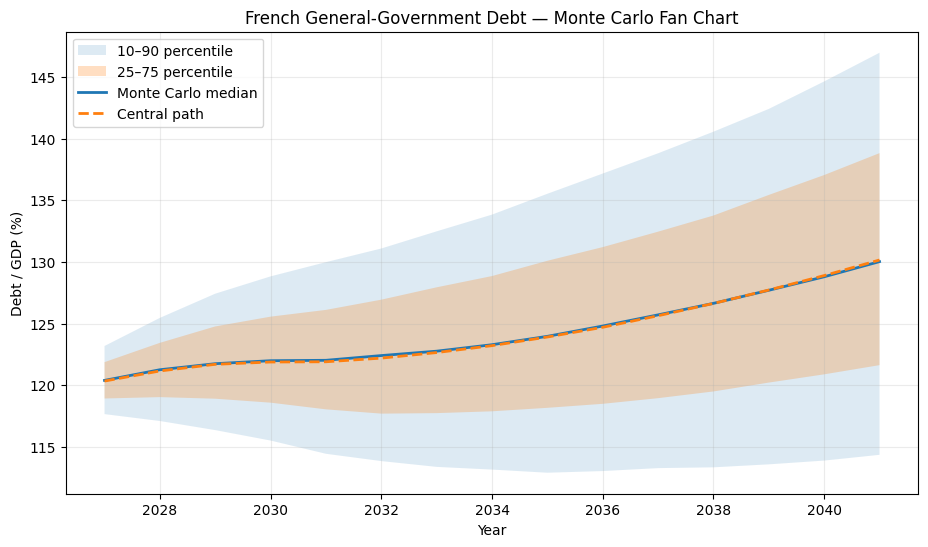

In [286]:
# ============================================================
# Debt/GDP fan chart
# ============================================================

fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.fill_between(
    debt_fan["year"],
    debt_fan["p10"] * 100,
    debt_fan["p90"] * 100,
    alpha=0.15,
    label="10–90 percentile",
)

ax.fill_between(
    debt_fan["year"],
    debt_fan["p25"] * 100,
    debt_fan["p75"] * 100,
    alpha=0.25,
    label="25–75 percentile",
)

ax.plot(
    debt_fan["year"],
    debt_fan["p50"] * 100,
    linewidth=2,
    label="Monte Carlo median",
)

ax.plot(
    gg_central_path["year"],
    gg_central_path["debt_gdp_end"] * 100,
    linestyle="--",
    linewidth=2,
    label="Central path",
)

ax.set_title(
    "French General-Government Debt — Monte Carlo Fan Chart"
)

ax.set_xlabel("Year")
ax.set_ylabel("Debt / GDP (%)")
ax.grid(alpha=0.25)
ax.legend()

plt.show()

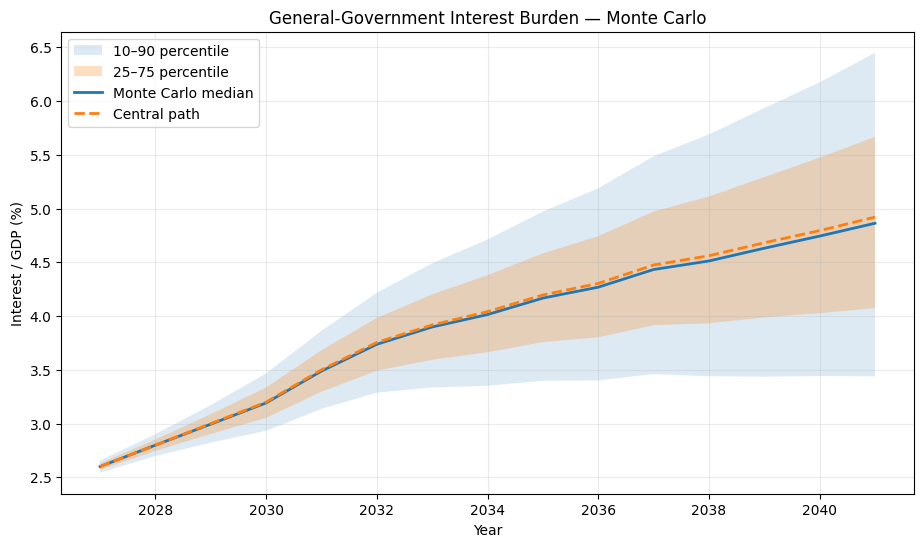

In [287]:
# ============================================================
# Interest/GDP fan chart
# ============================================================

fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.fill_between(
    interest_fan["year"],
    interest_fan["p10"] * 100,
    interest_fan["p90"] * 100,
    alpha=0.15,
    label="10–90 percentile",
)

ax.fill_between(
    interest_fan["year"],
    interest_fan["p25"] * 100,
    interest_fan["p75"] * 100,
    alpha=0.25,
    label="25–75 percentile",
)

ax.plot(
    interest_fan["year"],
    interest_fan["p50"] * 100,
    linewidth=2,
    label="Monte Carlo median",
)

ax.plot(
    gg_central_path["year"],
    gg_central_path["interest_gdp"] * 100,
    linestyle="--",
    linewidth=2,
    label="Central path",
)

ax.set_title(
    "General-Government Interest Burden — Monte Carlo"
)

ax.set_xlabel("Year")
ax.set_ylabel("Interest / GDP (%)")
ax.grid(alpha=0.25)
ax.legend()

plt.show()

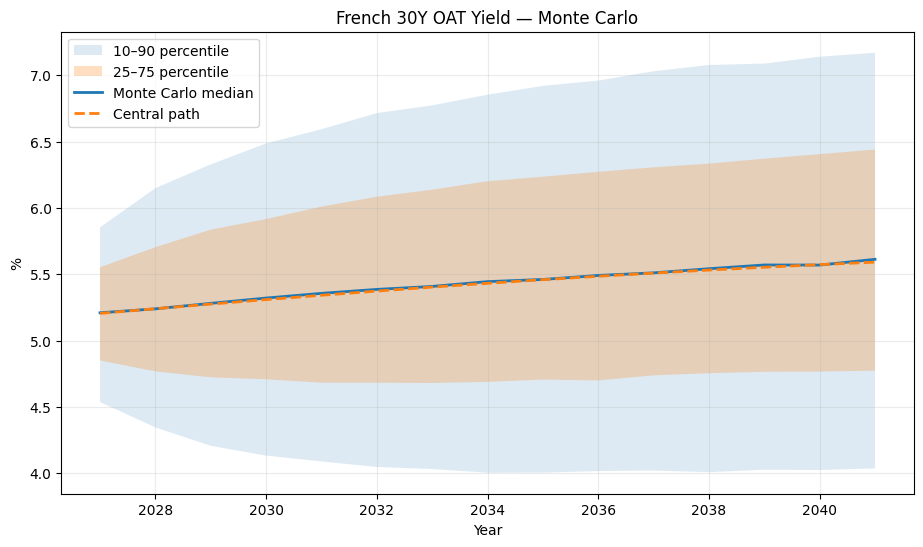

In [288]:
# ============================================================
# 30Y OAT fan chart
# ============================================================

fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.fill_between(
    oat_fan["year"],
    oat_fan["p10"] * 100,
    oat_fan["p90"] * 100,
    alpha=0.15,
    label="10–90 percentile",
)

ax.fill_between(
    oat_fan["year"],
    oat_fan["p25"] * 100,
    oat_fan["p75"] * 100,
    alpha=0.25,
    label="25–75 percentile",
)

ax.plot(
    oat_fan["year"],
    oat_fan["p50"] * 100,
    linewidth=2,
    label="Monte Carlo median",
)

ax.plot(
    central_mc.index,
    central_mc["oat_30y"] * 100,
    linestyle="--",
    linewidth=2,
    label="Central path",
)

ax.set_title(
    "French 30Y OAT Yield — Monte Carlo"
)

ax.set_xlabel("Year")
ax.set_ylabel("%")
ax.grid(alpha=0.25)
ax.legend()

plt.show()

## 13. Debt-sustainability probabilities

In [289]:
# ============================================================
# Headline risk probabilities
# ============================================================

terminal_debt = (
    mc[
        "debt_gdp"
    ][
        :,
        -1,
    ]
)

terminal_interest = (
    mc[
        "interest_gdp"
    ][
        :,
        -1,
    ]
)

terminal_oat = (
    mc[
        "oat_30y"
    ][
        :,
        -1,
    ]
)


# ------------------------------------------------------------
# Five-year debt deterioration
# ------------------------------------------------------------

initial_debt_column = np.full(
    (
        N_SIMULATIONS,
        1,
    ),
    BASELINE[
        "initial_debt_gdp"
    ],
)

debt_with_initial = np.concatenate(
    [
        initial_debt_column,
        mc[
            "debt_gdp"
        ],
    ],
    axis=1,
)

five_year_debt_changes = (
    debt_with_initial[
        :,
        5:,
    ]
    -
    debt_with_initial[
        :,
        :-5,
    ]
)


# ------------------------------------------------------------
# Probability table
# ------------------------------------------------------------

risk_probabilities = pd.DataFrame({
    "metric": [
        "Debt/GDP > 130% in 2041",
        "Debt/GDP > 150% in 2041",
        "Debt/GDP > 175% in 2041",
        "Debt/GDP above 2026 level in 2041",
        "Debt rises >20 pp within any 5-year window",
        "Interest/GDP exceeds 4% at least once",
        "Interest/GDP exceeds 5% at least once",
        "30Y OAT exceeds 6% at least once",
        "30Y OAT exceeds 7% at least once",
        "30Y OAT > 6% in 2041",
        "30Y OAT > 7% in 2041",
    ],

    "probability": [
        np.mean(
            terminal_debt
            > 1.30
        ),

        np.mean(
            terminal_debt
            > 1.50
        ),

        np.mean(
            terminal_debt
            > 1.75
        ),

        np.mean(
            terminal_debt
            >
            BASELINE[
                "initial_debt_gdp"
            ]
        ),

        np.mean(
            np.any(
                five_year_debt_changes
                > 0.20,
                axis=1,
            )
        ),

        np.mean(
            np.any(
                mc[
                    "interest_gdp"
                ]
                > 0.04,
                axis=1,
            )
        ),

        np.mean(
            np.any(
                mc[
                    "interest_gdp"
                ]
                > 0.05,
                axis=1,
            )
        ),

        np.mean(
            np.any(
                mc[
                    "oat_30y"
                ]
                > 0.06,
                axis=1,
            )
        ),

        np.mean(
            np.any(
                mc[
                    "oat_30y"
                ]
                > 0.07,
                axis=1,
            )
        ),

        np.mean(
            terminal_oat
            > 0.06
        ),

        np.mean(
            terminal_oat
            > 0.07
        ),
    ],
})

risk_probabilities[
    "probability_pct"
] = (
    risk_probabilities[
        "probability"
    ]
    * 100
)

risk_probabilities[
    [
        "metric",
        "probability_pct",
    ]
].round(
    2
)

,metric,probability_pct
0,Debt/GDP > 130% in 2041,50.07
1,Debt/GDP > 150% in 2041,6.63
2,Debt/GDP > 175% in 2041,0.05
3,Debt/GDP above 2026 level in 2041,82.55
4,Debt rises >20 pp within any 5-year window,6.81
5,Interest/GDP exceeds 4% at least once,80.66
6,Interest/GDP exceeds 5% at least once,45.91
7,30Y OAT exceeds 6% at least once,70.70
8,30Y OAT exceeds 7% at least once,29.51
9,30Y OAT > 6% in 2041,37.73


In [290]:
# ============================================================
# Terminal debt distribution
# ============================================================

terminal_debt_summary = pd.Series({
    "p05":
        np.percentile(
            terminal_debt,
            5,
        ),

    "p10":
        np.percentile(
            terminal_debt,
            10,
        ),

    "p25":
        np.percentile(
            terminal_debt,
            25,
        ),

    "median":
        np.percentile(
            terminal_debt,
            50,
        ),

    "mean":
        np.mean(
            terminal_debt
        ),

    "p75":
        np.percentile(
            terminal_debt,
            75,
        ),

    "p90":
        np.percentile(
            terminal_debt,
            90,
        ),

    "p95":
        np.percentile(
            terminal_debt,
            95,
        ),
})

(
    terminal_debt_summary
    * 100
).round(
    2
).to_frame(
    "Debt/GDP in 2041 (%)"
)

,Debt/GDP in 2041 (%)
p05,109.62
p10,114.36
p25,121.63
median,130.03
mean,130.37
p75,138.83
p90,146.97
p95,151.92


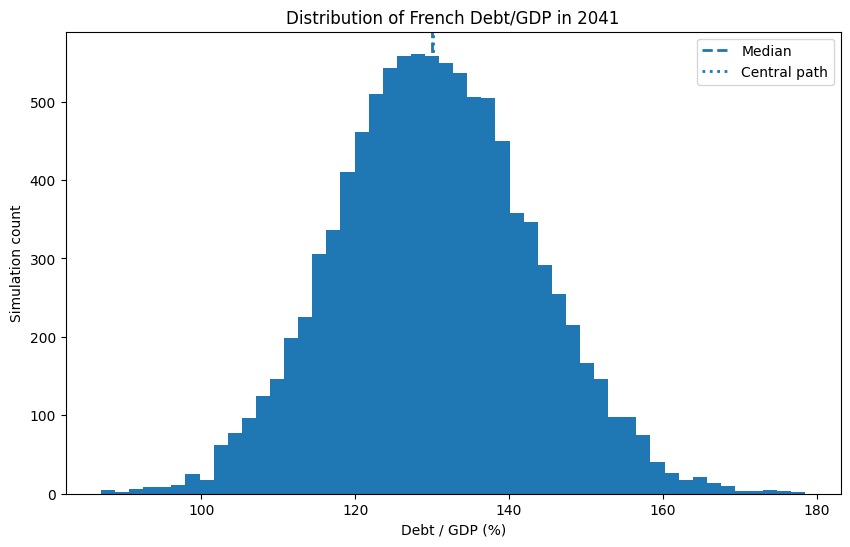

In [291]:
# ============================================================
# Terminal debt histogram
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.hist(
    terminal_debt
    * 100,
    bins=50,
)

ax.axvline(
    np.median(
        terminal_debt
    )
    * 100,
    linestyle="--",
    linewidth=2,
    label="Median",
)

ax.axvline(
    gg_central_path[
        "debt_gdp_end"
    ]
    .iloc[-1]
    * 100,
    linestyle=":",
    linewidth=2,
    label="Central path",
)

ax.set_title(
    "Distribution of French Debt/GDP in 2041"
)

ax.set_xlabel(
    "Debt / GDP (%)"
)

ax.set_ylabel(
    "Simulation count"
)

ax.legend()

plt.show()

## 14. Save Monte Carlo outputs

In [292]:
# ============================================================
# Save compact Monte Carlo arrays, regime metadata and summaries
# ============================================================

MONTE_CARLO_DIR = (
    PROCESSED_DIR
    / "monte_carlo"
)

MONTE_CARLO_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


monte_carlo_payload = {
    "years":
        mc[
            "years"
        ],

    "real_growth":
        mc[
            "real_growth"
        ],

    "inflation":
        mc[
            "inflation"
        ],

    "nominal_growth":
        mc[
            "nominal_growth"
        ],

    "primary_balance_gdp":
        mc[
            "primary_balance_gdp"
        ],

    "bund_10y":
        mc[
            "bund_10y"
        ],

    "france_spread_10y":
        mc[
            "france_spread_10y"
        ],

    "oat_30y":
        mc[
            "oat_30y"
        ],

    "aft_effective_financing_rate":
        mc[
            "aft_effective_financing_rate"
        ],

    "aft_cost_shock_eur":
        mc[
            "aft_cost_shock_eur"
        ],

    "gg_effective_rate":
        mc[
            "gg_effective_rate"
        ],

    "interest_gdp":
        mc[
            "interest_gdp"
        ],

    "debt_gdp":
        mc[
            "debt_gdp"
        ],

    # Calibration metadata
    "baseline_oat_30y":
        np.array(
            [
                BASELINE_OAT_30Y
            ]
        ),

    "market_anchor_date":
        np.array(
            [
                str(
                    MARKET_ANCHOR_DATE.date()
                )
            ]
        ),

    "bund_historical_long_run_mean":
        np.array(
            [
                HISTORICAL_BUND_LONG_RUN
            ]
        ),

    "bund_forward_10y10y":
        np.array(
            [
                BUND_FORWARD_10Y10Y
            ]
        ),

    "bund_forward_15y10y":
        np.array(
            [
                BUND_FORWARD_15Y10Y
            ]
        ),

    "bund_svensson_beta0":
        np.array(
            [
                BUND_SVENSSON_BETA0
            ]
        ),

    "bund_market_implied_long_run":
        np.array(
            [
                MARKET_IMPLIED_BUND_LONG_RUN
            ]
        ),

    "bund_regime_weight":
        np.array(
            [
                BUND_REGIME_WEIGHT
            ]
        ),

    "bund_selected_long_run":
        np.array(
            [
                SELECTED_BUND_LONG_RUN
            ]
        ),

    "france_spread_selected_long_run":
        np.array(
            [
                SELECTED_FRANCE_SPREAD_LONG_RUN
            ]
        ),
}


# Canonical file consumed by Notebook 03.
np.savez_compressed(
    MONTE_CARLO_DIR
    / "monte_carlo_10000_paths.npz",
    **monte_carlo_payload,
)


# Regime-specific archival copy.
np.savez_compressed(
    MONTE_CARLO_DIR
    / "monte_carlo_10000_paths_market_regime.npz",
    **monte_carlo_payload,
)


debt_fan.to_csv(
    MONTE_CARLO_DIR
    / "debt_fan_percentiles.csv",
    index=False,
)

interest_fan.to_csv(
    MONTE_CARLO_DIR
    / "interest_fan_percentiles.csv",
    index=False,
)

oat_fan.to_csv(
    MONTE_CARLO_DIR
    / "oat_fan_percentiles.csv",
    index=False,
)

risk_probabilities.to_csv(
    MONTE_CARLO_DIR
    / "risk_probabilities.csv",
    index=False,
)


market_regime_calibration = pd.DataFrame({
    "metric": [
        "market_anchor_date",
        "historical_bund_long_run",
        "bund_forward_10y10y",
        "bund_forward_15y10y",
        "bund_svensson_beta0",
        "market_implied_bund_long_run",
        "regime_weight",
        "selected_bund_long_run",
        "selected_france_spread_long_run",
        "observed_2026_oat_30y",
    ],

    "value": [
        str(
            MARKET_ANCHOR_DATE.date()
        ),
        HISTORICAL_BUND_LONG_RUN,
        BUND_FORWARD_10Y10Y,
        BUND_FORWARD_15Y10Y,
        BUND_SVENSSON_BETA0,
        MARKET_IMPLIED_BUND_LONG_RUN,
        BUND_REGIME_WEIGHT,
        SELECTED_BUND_LONG_RUN,
        SELECTED_FRANCE_SPREAD_LONG_RUN,
        CURRENT_OAT_30Y,
    ],
})

market_regime_calibration.to_csv(
    MONTE_CARLO_DIR
    / "market_regime_calibration.csv",
    index=False,
)


print(
    "Monte Carlo outputs saved to:",
    MONTE_CARLO_DIR,
)

print(
    "Selected Bund structural anchor:",
    f"{SELECTED_BUND_LONG_RUN:.2%}",
)

Monte Carlo outputs saved to: c:\Users\mikel\Desktop\french_oat_model\data\processed\monte_carlo
Selected Bund structural anchor: 4.13%


# Monte Carlo stage complete

The stochastic DSA now produces:

- 10,000 full macro/market/debt paths;
- debt/GDP fan charts;
- interest/GDP fan charts;
- 30Y OAT fan charts;
- terminal debt distributions;
- debt-threshold probabilities;
- interest-burden probabilities;
- long-yield stress probabilities;
- five-year debt-deterioration probabilities;
- compressed arrays for later sensitivity analysis.

The simulation represents **ordinary-times uncertainty calibrated with the robust covariance estimator**. Historical crisis observations identified as multivariate outliers remain separate explicit stress scenarios rather than routine annual draws.

## Interpretation of the revised rate process

The revised simulation no longer assumes that today's Bund yield must eventually revert
to the average level observed across the full historical calibration sample.

Instead:

- **persistence and shocks** remain historically estimated;
- the **long-run Bund center** is market-implied from the current German zero-coupon curve;
- the ordinary-times France spread retains its historical mean;
- Notebook 03 continues to add the separate nonlinear fiscal/debt sovereign-risk premium.

This deliberately separates the common European interest-rate regime from France-specific
sovereign stress.